In [1]:
# ╔══════════════════════════════════════════════════╗
# ║  SEL 1: INSTALL DAN IMPORT LIBRARY                       ║
# ╚═══════════════════════════════════════════════════╝

# Install library lain terlebih dahulu (biarkan mereka menginstall numpy sesuai kebutuhan)
!pip install rembg -q
!pip install onnxruntime -q

!pip install numpy==1.26.4 -q --force-reinstall
!pip install scikit-learn -q --force-reinstall

import os
import sys
import json
import random
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime
from pathlib import Path
from PIL import Image, ImageEnhance
import cv2

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

from rembg import remove

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 150

print("✅ Install selesai. WAJIB restart runtime sekarang!")
print("   Klik menu: Runtime → Restart Runtime")
print("   Setelah restart, jalankan sel ini lagi dari baris import di bawah.")
print("   (Jangan jalankan bagian install di atas lagi)")

print("=" * 60)
print("KLASIFIKASI GABAH SEBAGAI ANOMALI VISUAL PADA TUMPUKAN BERAS")
print("CNN Berbasis MobileNetV2 | Transfer Learning + Fine-Tuning")
print("=" * 60)
print(f"TensorFlow version : {tf.__version__}")
print(f"Python version     : {sys.version.split()[0]}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU tersedia       : {gpus if gpus else 'Tidak ada (CPU mode)'}")
print("=" * 60)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rembg 2.0.72 requires numpy<3.0.0,>=2.3.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requir

In [2]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SEL 2: MOUNT GOOGLE DRIVE                               ║
# ╚══════════════════════════════════════════════════════════╝

from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive berhasil di-mount!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive berhasil di-mount!


In [3]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SEL 3: KONFIGURASI PATH & SEED (REPRODUCIBILITY)        ║
# ╚══════════════════════════════════════════════════════════╝

# ─── SEED GLOBAL (agar hasil selalu sama setiap run) ───────
# ─── SEED GLOBAL ────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
print(f"✅ Seed global ditetapkan: {SEED}")

# ─── PATH KONFIGURASI ───────────────────────────────────────
DRIVE_BASE    = '/content/drive/MyDrive'

DATASET_DIR   = os.path.join(DRIVE_BASE, 'Dataset')
CLASS_BERAS   = os.path.join(DATASET_DIR, 'beras_normal')
CLASS_GABAH   = os.path.join(DATASET_DIR, 'gabah_anomali')

OUTPUT_BASE       = os.path.join(DRIVE_BASE, 'Hasil_Penelitian')
PREPROCESSED_DIR  = os.path.join(OUTPUT_BASE, 'preprocessed_dataset')
MODEL_DIR         = os.path.join(OUTPUT_BASE, 'model')
PLOT_DIR          = os.path.join(OUTPUT_BASE, 'plots')
REPORT_DIR        = os.path.join(OUTPUT_BASE, 'reports')
GRADCAM_DIR       = os.path.join(OUTPUT_BASE, 'gradcam')

# ── FIX: Keras baru wajib pakai .weights.h5 ─────────────────
MODEL_PHASE1_PATH = os.path.join(MODEL_DIR, 'model_phase1_best.weights.h5')
MODEL_PHASE2_PATH = os.path.join(MODEL_DIR, 'model_phase2_best.weights.h5')
MODEL_FINAL_PATH  = os.path.join(MODEL_DIR, 'model_final.keras')   # format keras baru

SPLIT_INFO_PATH   = os.path.join(OUTPUT_BASE, 'split_info.json')
HISTORY_PATH      = os.path.join(OUTPUT_BASE, 'training_history.json')
PREPROCESSED_FLAG = os.path.join(OUTPUT_BASE, 'preprocessing_done.flag')

for d in [OUTPUT_BASE, PREPROCESSED_DIR, MODEL_DIR, PLOT_DIR,
          REPORT_DIR, GRADCAM_DIR,
          os.path.join(PREPROCESSED_DIR, 'beras_normal'),
          os.path.join(PREPROCESSED_DIR, 'gabah_anomali')]:
    os.makedirs(d, exist_ok=True)

print("✅ Semua folder output siap.")

# ─── HYPERPARAMETER ─────────────────────────────────────────
IMG_SIZE       = (224, 224)
BATCH_SIZE     = 32
EPOCHS_PHASE1  = 30
EPOCHS_PHASE2  = 20
LR_PHASE1      = 1e-3
LR_PHASE2      = 1e-5
FINE_TUNE_AT   = 30
TRAIN_RATIO    = 0.70
VAL_RATIO      = 0.15
TEST_RATIO     = 0.15

# ─── WARNA BACKGROUND ────────────────────────────────────────
BG_COLORS = {
    'putih'     : (255, 255, 255),
    'krem'      : (255, 253, 208),
    'tan'       : (210, 180, 140),
    'abu_muda'  : (192, 192, 192),
    'abu_gelap' : (105, 105, 105),
}
BG_COLOR_LIST  = list(BG_COLORS.values())
BG_COLOR_NAMES = list(BG_COLORS.keys())

CLASS_NAMES = ['beras_normal', 'gabah_anomali']

print(f"\n📁 Dataset Input  : {DATASET_DIR}")
print(f"📁 Hasil Output   : {OUTPUT_BASE}")
print(f"💾 Model Fase 1   : {MODEL_PHASE1_PATH}")
print(f"💾 Model Fase 2   : {MODEL_PHASE2_PATH}")

✅ Seed global ditetapkan: 42
✅ Semua folder output siap.

📁 Dataset Input  : /content/drive/MyDrive/Dataset
📁 Hasil Output   : /content/drive/MyDrive/Hasil_Penelitian
💾 Model Fase 1   : /content/drive/MyDrive/Hasil_Penelitian/model/model_phase1_best.weights.h5
💾 Model Fase 2   : /content/drive/MyDrive/Hasil_Penelitian/model/model_phase2_best.weights.h5


In [4]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SEL 4: FUNGSI HELPER UMUM                               ║
# ╚══════════════════════════════════════════════════════════╝

def get_image_paths(folder):
    """Ambil semua path gambar dari folder."""
    exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    paths = [str(p) for p in Path(folder).rglob('*')
             if p.suffix.lower() in exts]
    return sorted(paths)

def generate_run_timestamp():
    """Buat timestamp untuk penamaan file unik tiap run."""
    return datetime.now().strftime('%Y%m%d_%H%M%S')

RUN_TIMESTAMP = generate_run_timestamp()
print(f"✅ Run timestamp: {RUN_TIMESTAMP}")

def save_figure(fig, name, subdir=None):
    """Simpan figure ke folder plot dengan nama unik per-run."""
    folder = os.path.join(PLOT_DIR, subdir) if subdir else PLOT_DIR
    os.makedirs(folder, exist_ok=True)
    # Simpan dengan timestamp agar tidak menimpa run sebelumnya
    fname = f"{name}_{RUN_TIMESTAMP}.png"
    fpath = os.path.join(folder, fname)
    fig.savefig(fpath, bbox_inches='tight', dpi=150)
    print(f"   💾 Gambar disimpan: {fpath}")
    plt.show()
    return fpath

def save_report(content, name):
    """Simpan teks laporan ke folder reports dengan timestamp."""
    fname = f"{name}_{RUN_TIMESTAMP}.txt"
    fpath = os.path.join(REPORT_DIR, fname)
    with open(fpath, 'w', encoding='utf-8') as f:
        f.write(content)
    print(f"   💾 Laporan disimpan: {fpath}")
    return fpath

✅ Run timestamp: 20260314_050848


In [5]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SEL 5: CEK DATASET INPUT                                ║
# ╚══════════════════════════════════════════════════════════╝

print("\n" + "="*50)
print("📊 CEK DATASET INPUT")
print("="*50)

beras_paths = get_image_paths(CLASS_BERAS)
gabah_paths = get_image_paths(CLASS_GABAH)

print(f"Kelas beras_normal  : {len(beras_paths)} citra")
print(f"Kelas gabah_anomali : {len(gabah_paths)} citra")
print(f"Total dataset       : {len(beras_paths) + len(gabah_paths)} citra")

assert len(beras_paths) > 0, f"❌ Folder kosong: {CLASS_BERAS}"
assert len(gabah_paths) > 0, f"❌ Folder kosong: {CLASS_GABAH}"
print("\n✅ Dataset input valid!")

# Tampilkan contoh citra asli
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Contoh Citra Asli Dataset (Sebelum Praproses)', fontsize=13, fontweight='bold')

sample_beras = random.sample(beras_paths, min(5, len(beras_paths)))
sample_gabah = random.sample(gabah_paths, min(5, len(gabah_paths)))

for i, p in enumerate(sample_beras):
    img = Image.open(p).resize((224, 224))
    axes[0, i].imshow(img)
    axes[0, i].set_title('Beras Normal', fontsize=9)
    axes[0, i].axis('off')

for i, p in enumerate(sample_gabah):
    img = Image.open(p).resize((224, 224))
    axes[1, i].imshow(img)
    axes[1, i].set_title('Gabah Anomali', fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
save_figure(fig, 'citra_asli_dataset')

Output hidden; open in https://colab.research.google.com to view.

In [6]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SEL 6: PRAPROSES - BACKGROUND REMOVAL & RANDOM BG       ║
# ╚══════════════════════════════════════════════════════════╝

print("\n" + "="*50)
print("🔧 TAHAP PRAPROSES DATA")
print("="*50)

def remove_background_and_apply_random_bg(img_path, output_path, seed_offset=0):
    """
    Praproses citra:
    1. Background removal menggunakan rembg
    2. Tempel ke background warna acak (5 variasi)
    Mengembalikan (before_img, after_img, bg_color_name)
    """
    # Baca gambar asli
    with open(img_path, 'rb') as f:
        input_data = f.read()

    # Remove background → menghasilkan RGBA
    output_data = remove(input_data)
    fg_img = Image.open(__import__('io').BytesIO(output_data)).convert('RGBA')

    # Pilih warna background secara deterministik berdasarkan nama file
    fname_hash = hash(os.path.basename(img_path) + str(seed_offset)) % len(BG_COLOR_LIST)
    rng = random.Random(SEED + abs(fname_hash))
    color_idx = rng.randint(0, len(BG_COLOR_LIST) - 1)
    bg_color  = BG_COLOR_LIST[color_idx]
    bg_name   = BG_COLOR_NAMES[color_idx]

    # Buat background solid dengan warna terpilih
    bg_img = Image.new('RGBA', fg_img.size, bg_color + (255,))

    # Composite: tempel foreground di atas background
    result = Image.alpha_composite(bg_img, fg_img).convert('RGB')
    result = result.resize(IMG_SIZE, Image.LANCZOS)

    # Simpan hasil
    result.save(output_path)

    # Kembalikan gambar untuk visualisasi
    before = Image.open(img_path).resize(IMG_SIZE, Image.LANCZOS)
    return before, result, bg_name


def preprocess_dataset(src_paths, src_label, out_folder, show_sample=True):
    """Proses semua gambar satu kelas."""
    out_class_dir = os.path.join(out_folder, src_label)
    os.makedirs(out_class_dir, exist_ok=True)

    sample_befores, sample_afters, sample_bgs = [], [], []

    for i, src_path in enumerate(src_paths):
        fname    = f"{src_label}_{i:04d}.jpg"
        out_path = os.path.join(out_class_dir, fname)

        before, after, bg_name = remove_background_and_apply_random_bg(
            src_path, out_path, seed_offset=i
        )

        # Ambil 5 sampel untuk visualisasi
        if i < 5:
            sample_befores.append(before)
            sample_afters.append(after)
            sample_bgs.append(bg_name)

        if (i + 1) % 50 == 0 or (i + 1) == len(src_paths):
            print(f"   [{src_label}] Diproses: {i+1}/{len(src_paths)}")

    return sample_befores, sample_afters, sample_bgs


# ─── CEK APAKAH PREPROCESSING SUDAH DILAKUKAN ───────────────
if os.path.exists(PREPROCESSED_FLAG):
    print("⏭️  Preprocessing sudah selesai sebelumnya. Lewati tahap ini.")
    print("   (Hapus file 'preprocessing_done.flag' di Drive jika ingin ulang)")
else:
    print("🔄 Mulai preprocessing dataset...")
    print("   Ini mungkin memakan waktu 10-30 menit tergantung jumlah gambar.")
    print()

    # Proses kelas beras_normal
    print("📌 Memproses kelas: beras_normal")
    b_befores, b_afters, b_bgs = preprocess_dataset(
        beras_paths, 'beras_normal', PREPROCESSED_DIR
    )

    # Proses kelas gabah_anomali
    print("\n📌 Memproses kelas: gabah_anomali")
    g_befores, g_afters, g_bgs = preprocess_dataset(
        gabah_paths, 'gabah_anomali', PREPROCESSED_DIR
    )

    # Tandai selesai
    with open(PREPROCESSED_FLAG, 'w') as f:
        f.write(f"done:{RUN_TIMESTAMP}")
    print("\n✅ Preprocessing selesai! Flag tersimpan di Drive.")

    # ── Visualisasi Before vs After (Beras Normal) ──────────
    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    fig.suptitle('Praproses: Before vs After (Beras Normal)\nBackground Removal + Random Background',
                 fontsize=12, fontweight='bold')

    for i in range(5):
        axes[0, i].imshow(b_befores[i])
        axes[0, i].set_title('Before', fontsize=9)
        axes[0, i].axis('off')

        axes[1, i].imshow(b_afters[i])
        axes[1, i].set_title(f'After\n(bg: {b_bgs[i]})', fontsize=8)
        axes[1, i].axis('off')

    plt.tight_layout()
    save_figure(fig, 'preprocessing_beras_normal')

    # ── Visualisasi Before vs After (Gabah Anomali) ─────────
    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    fig.suptitle('Praproses: Before vs After (Gabah Anomali)\nBackground Removal + Random Background',
                 fontsize=12, fontweight='bold')

    for i in range(5):
        axes[0, i].imshow(g_befores[i])
        axes[0, i].set_title('Before', fontsize=9)
        axes[0, i].axis('off')

        axes[1, i].imshow(g_afters[i])
        axes[1, i].set_title(f'After\n(bg: {g_bgs[i]})', fontsize=8)
        axes[1, i].axis('off')

    plt.tight_layout()
    save_figure(fig, 'preprocessing_gabah_anomali')

    # ── Visualisasi 5 Varian Background ─────────────────────
    print("\n🎨 Visualisasi 5 Varian Background yang Digunakan:")

    # Ambil 1 sampel beras dan 1 sampel gabah untuk demo warna
    demo_beras_src = beras_paths[0]
    demo_gabah_src = gabah_paths[0]

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    fig.suptitle('Demonstrasi 5 Variasi Warna Background\n(Atas: Beras Normal | Bawah: Gabah Anomali)',
                 fontsize=12, fontweight='bold')

    for idx, (color_name, color_val) in enumerate(BG_COLORS.items()):
        # Beras dengan bg warna ini
        with open(demo_beras_src, 'rb') as f:
            fg_data = remove(f.read())
        fg = Image.open(__import__('io').BytesIO(fg_data)).convert('RGBA')
        bg = Image.new('RGBA', fg.size, color_val + (255,))
        result_b = Image.alpha_composite(bg, fg).convert('RGB').resize(IMG_SIZE)

        # Gabah dengan bg warna ini
        with open(demo_gabah_src, 'rb') as f:
            fg_data2 = remove(f.read())
        fg2 = Image.open(__import__('io').BytesIO(fg_data2)).convert('RGBA')
        bg2 = Image.new('RGBA', fg2.size, color_val + (255,))
        result_g = Image.alpha_composite(bg2, fg2).convert('RGB').resize(IMG_SIZE)

        axes[0, idx].imshow(result_b)
        axes[0, idx].set_title(f'Beras\n({color_name})', fontsize=9)
        axes[0, idx].axis('off')

        axes[1, idx].imshow(result_g)
        axes[1, idx].set_title(f'Gabah\n({color_name})', fontsize=9)
        axes[1, idx].axis('off')

    plt.tight_layout()
    save_figure(fig, 'variasi_5_background')


🔧 TAHAP PRAPROSES DATA
⏭️  Preprocessing sudah selesai sebelumnya. Lewati tahap ini.
   (Hapus file 'preprocessing_done.flag' di Drive jika ingin ulang)



✂️  PEMBAGIAN DATASET
⏭️  Split sudah ada, load dari Drive...
   Training : 700 citra  (350 beras | 350 gabah)
   Validasi : 150 citra  (75 beras | 75 gabah)
   Testing  : 150 citra  (75 beras | 75 gabah)
   💾 Gambar disimpan: /content/drive/MyDrive/Hasil_Penelitian/plots/distribusi_dataset_seimbang_20260314_050848.png


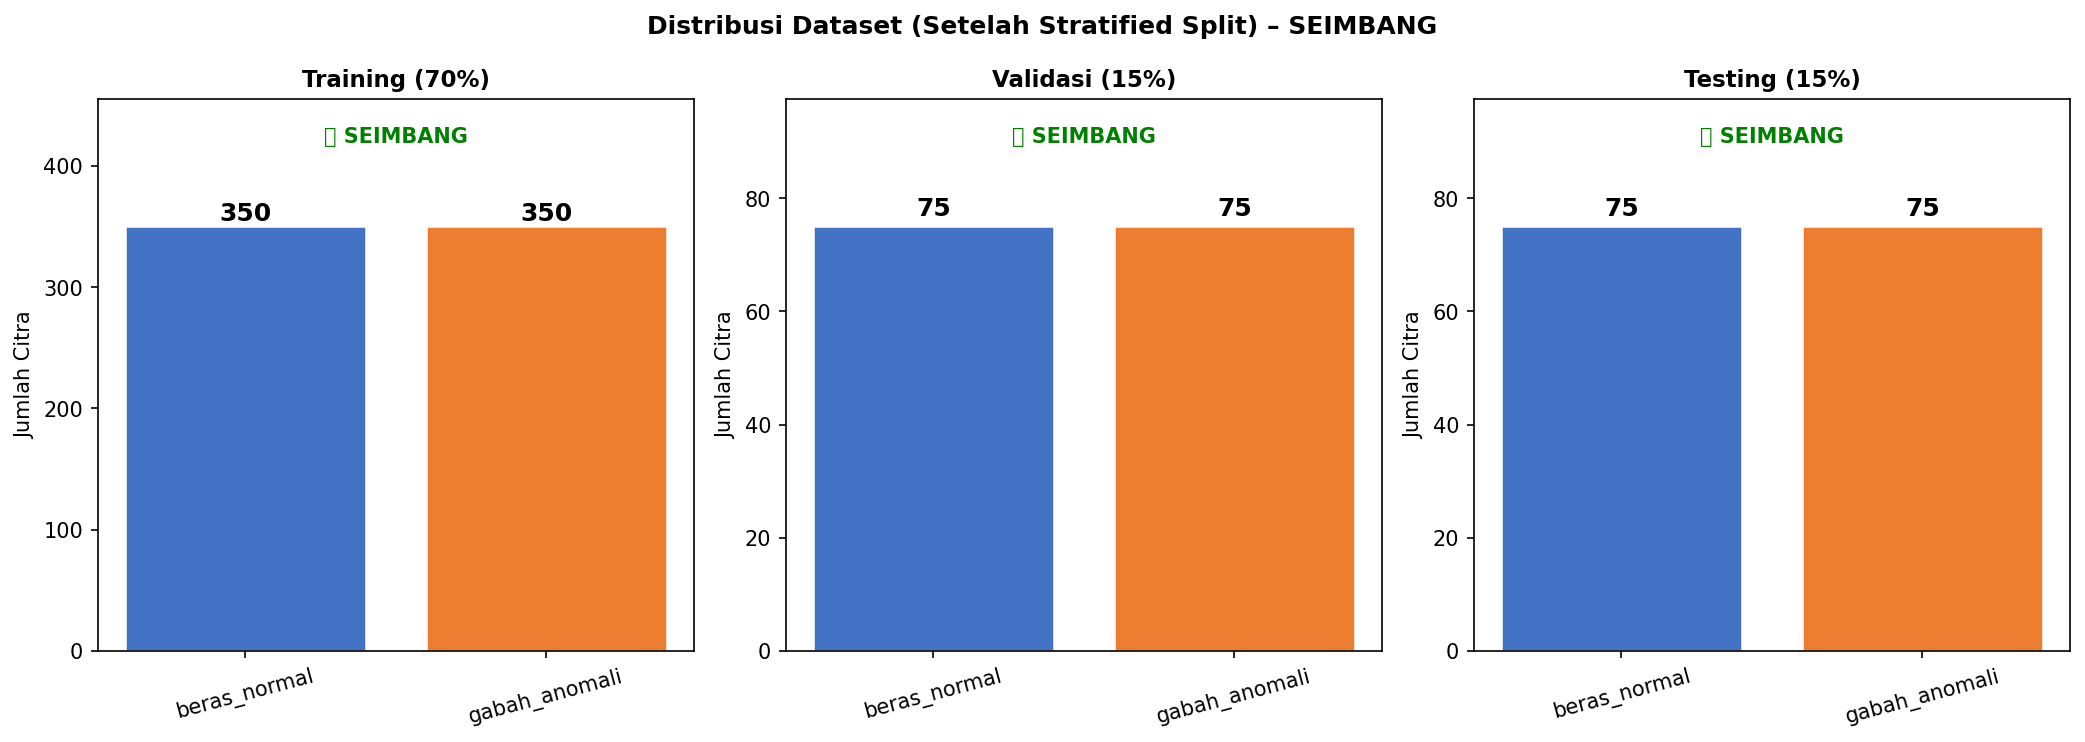

'/content/drive/MyDrive/Hasil_Penelitian/plots/distribusi_dataset_seimbang_20260314_050848.png'

In [7]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SEL 7: PEMBAGIAN DATASET (STRATIFIED SPLIT)             ║
# ╚══════════════════════════════════════════════════════════╝

print("\n" + "="*50)
print("✂️  PEMBAGIAN DATASET")
print("="*50)

def load_split_or_create(preprocessed_dir, split_path):
    """
    Load split dari JSON jika sudah ada.
    Jika belum ada, buat split SEIMBANG:
      - Ambil jumlah citra yang sama dari tiap kelas
      - 70% train / 15% val / 15% test PER KELAS
      - Hasil: tiap subset punya jumlah beras == jumlah gabah
    """
    if os.path.exists(split_path):
        print("⏭️  Split sudah ada, load dari Drive...")
        with open(split_path, 'r') as f:
            split = json.load(f)
        # Tampilkan info
        tl = split['train_labels']
        vl = split['val_labels']
        sl = split['test_labels']
        print(f"   Training : {len(tl)} citra  ({tl.count(0)} beras | {tl.count(1)} gabah)")
        print(f"   Validasi : {len(vl)} citra  ({vl.count(0)} beras | {vl.count(1)} gabah)")
        print(f"   Testing  : {len(sl)} citra  ({sl.count(0)} beras | {sl.count(1)} gabah)")
        return (split['train_paths'], split['train_labels'],
                split['val_paths'],   split['val_labels'],
                split['test_paths'],  split['test_labels'])

    print("🔄 Membuat split baru yang benar-benar seimbang...")

    # ── Kumpulkan path per kelas ─────────────────────────────
    paths_per_class = {}
    for cls_name in CLASS_NAMES:
        cls_dir = os.path.join(preprocessed_dir, cls_name)
        paths_per_class[cls_name] = sorted(get_image_paths(cls_dir))

    # ── Samakan jumlah per kelas (ambil minimum) ─────────────
    min_count = min(len(v) for v in paths_per_class.values())
    print(f"   Jumlah citra per kelas (setelah disamakan): {min_count}")

    # ── Split per kelas secara terpisah agar pasti seimbang ──
    # Hitung per kelas: berapa train/val/test
    n_test  = int(min_count * TEST_RATIO)
    n_val   = int(min_count * VAL_RATIO)
    n_train = min_count - n_val - n_test

    print(f"   Per kelas → train: {n_train} | val: {n_val} | test: {n_test}")
    print(f"   Total    → train: {n_train*2} | val: {n_val*2} | test: {n_test*2}")

    all_train_paths, all_train_labels = [], []
    all_val_paths,   all_val_labels   = [], []
    all_test_paths,  all_test_labels  = [], []

    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        cls_paths = paths_per_class[cls_name][:min_count]  # ambil min_count saja

        # Shuffle deterministik per kelas
        rng = random.Random(SEED + cls_idx)
        rng.shuffle(cls_paths)

        # Potong langsung (tidak pakai sklearn agar benar-benar deterministik)
        test_p  = cls_paths[:n_test]
        val_p   = cls_paths[n_test : n_test + n_val]
        train_p = cls_paths[n_test + n_val : n_test + n_val + n_train]

        all_train_paths.extend(train_p)
        all_train_labels.extend([cls_idx] * len(train_p))
        all_val_paths.extend(val_p)
        all_val_labels.extend([cls_idx] * len(val_p))
        all_test_paths.extend(test_p)
        all_test_labels.extend([cls_idx] * len(test_p))

    # ── Shuffle seluruh train secara deterministik ────────────
    combined_train = list(zip(all_train_paths, all_train_labels))
    random.Random(SEED).shuffle(combined_train)
    all_train_paths, all_train_labels = zip(*combined_train)
    all_train_paths  = list(all_train_paths)
    all_train_labels = list(all_train_labels)

    # ── Simpan ke JSON ────────────────────────────────────────
    split = {
        'train_paths' : all_train_paths, 'train_labels': all_train_labels,
        'val_paths'   : all_val_paths,   'val_labels'  : all_val_labels,
        'test_paths'  : all_test_paths,  'test_labels' : all_test_labels,
    }
    with open(split_path, 'w') as f:
        json.dump(split, f)

    tl = all_train_labels
    vl = all_val_labels
    sl = all_test_labels
    print(f"\n   ✅ Split tersimpan: {split_path}")
    print(f"   Training : {len(tl)} citra  ({tl.count(0)} beras | {tl.count(1)} gabah)")
    print(f"   Validasi : {len(vl)} citra  ({vl.count(0)} beras | {vl.count(1)} gabah)")
    print(f"   Testing  : {len(sl)} citra  ({sl.count(0)} beras | {sl.count(1)} gabah)")

    return (all_train_paths, all_train_labels,
            all_val_paths,   all_val_labels,
            all_test_paths,  all_test_labels)


# ── HAPUS split lama jika ada (agar dibuat ulang yang seimbang)
# Uncomment baris di bawah HANYA jika ingin reset split:
# if os.path.exists(SPLIT_INFO_PATH): os.remove(SPLIT_INFO_PATH)

train_paths, train_labels, val_paths, val_labels, test_paths, test_labels = \
    load_split_or_create(PREPROCESSED_DIR, SPLIT_INFO_PATH)

train_labels_np = np.array(train_labels)
val_labels_np   = np.array(val_labels)
test_labels_np  = np.array(test_labels)

# ── Visualisasi distribusi ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Distribusi Dataset (Setelah Stratified Split) – SEIMBANG',
             fontsize=12, fontweight='bold')

for ax, (split_name, labels) in zip(axes, [
    ('Training (70%)', train_labels_np),
    ('Validasi (15%)', val_labels_np),
    ('Testing (15%)',  test_labels_np),
]):
    counts = [int(np.sum(labels == 0)), int(np.sum(labels == 1))]
    colors = ['#4472C4', '#ED7D31']
    bars   = ax.bar(CLASS_NAMES, counts, color=colors, edgecolor='white', linewidth=1.2)
    ax.set_title(split_name, fontsize=11, fontweight='bold')
    ax.set_ylabel('Jumlah Citra')
    ax.set_ylim(0, max(counts) * 1.3)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(cnt), ha='center', va='bottom', fontweight='bold', fontsize=12)
    ax.tick_params(axis='x', rotation=15)

    # Tambahkan keterangan seimbang
    if counts[0] == counts[1]:
        ax.text(0.5, 0.95, '✅ SEIMBANG', transform=ax.transAxes,
                ha='center', va='top', fontsize=10, color='green', fontweight='bold')

plt.tight_layout()
save_figure(fig, 'distribusi_dataset_seimbang')


⚙️  DATA GENERATOR & AUGMENTASI
✅ Train dataset  : 700 citra | augmentasi=True
✅ Val dataset    : 150 citra   | augmentasi=False
✅ Test dataset   : 150 citra  | augmentasi=False

🖼️  Visualisasi contoh augmentasi data latih:
   💾 Gambar disimpan: /content/drive/MyDrive/Hasil_Penelitian/plots/contoh_augmentasi_20260314_050848.png


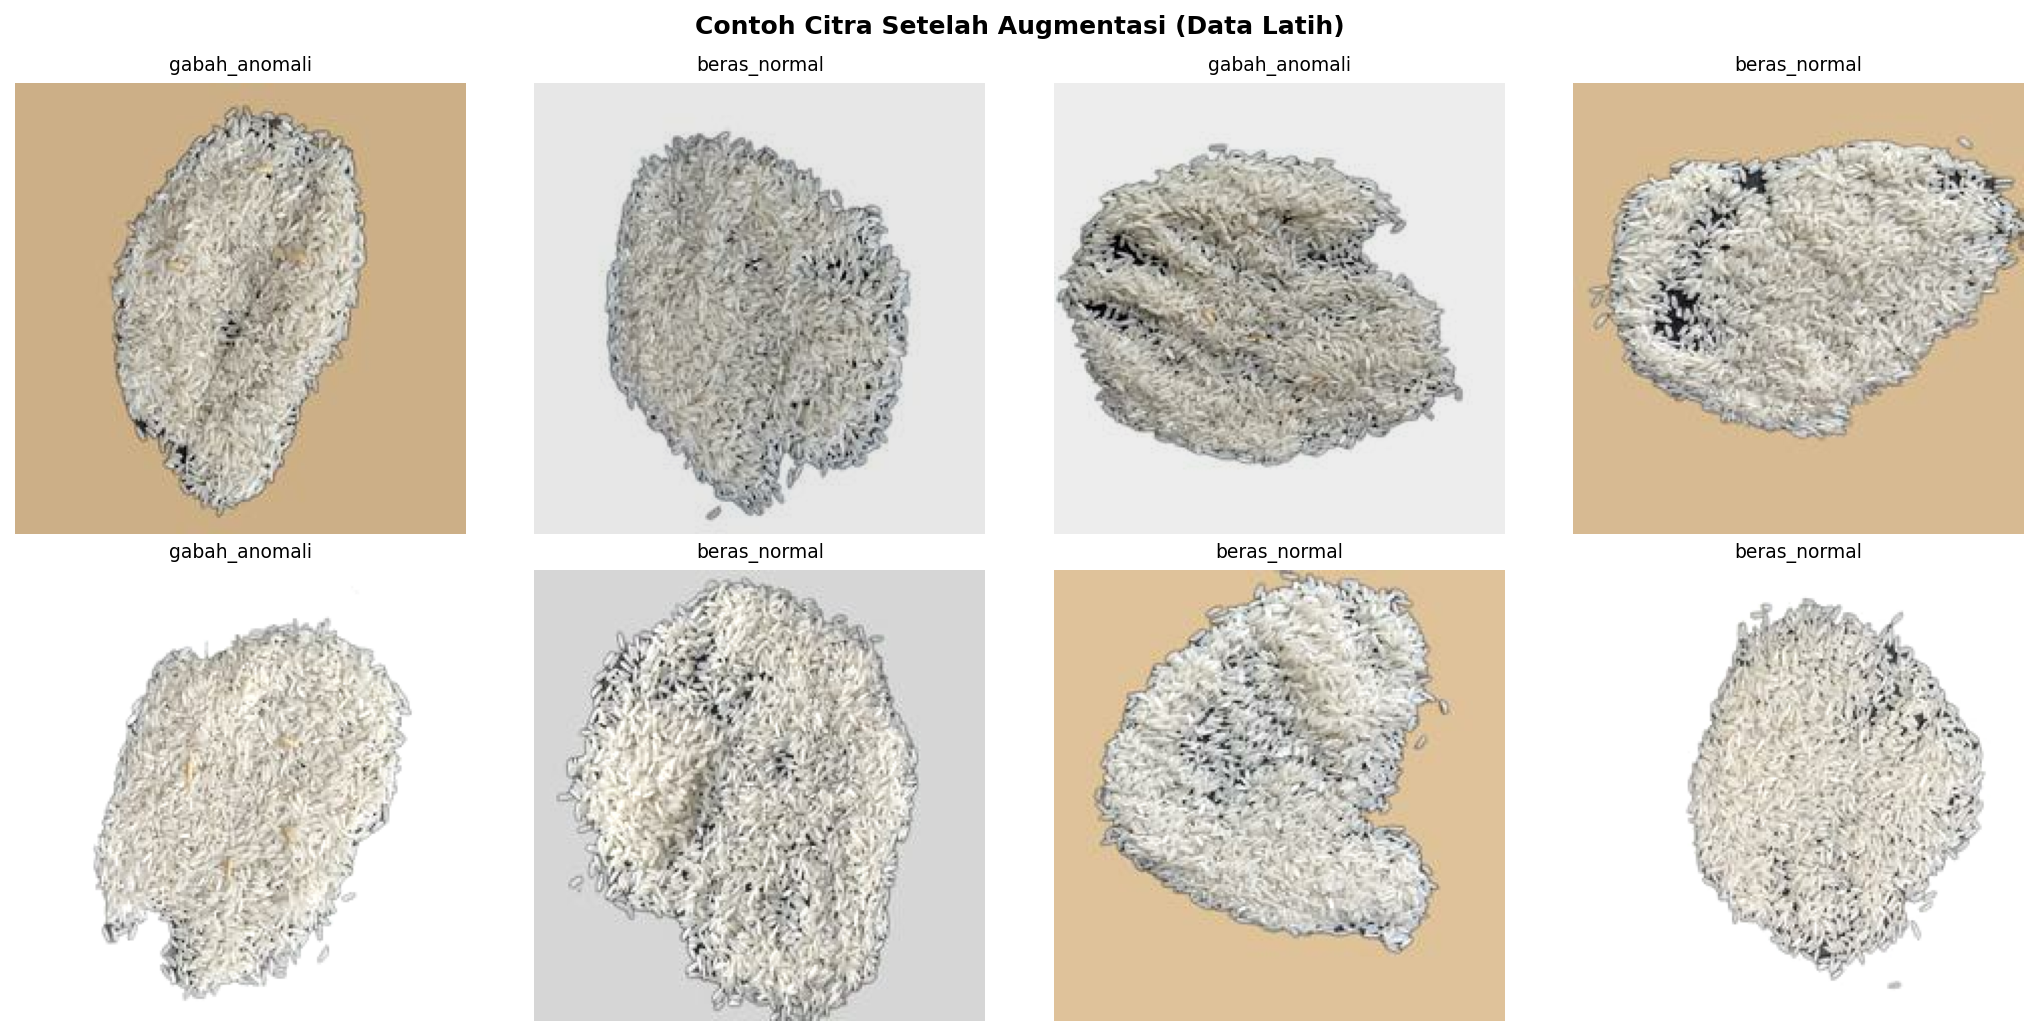

'/content/drive/MyDrive/Hasil_Penelitian/plots/contoh_augmentasi_20260314_050848.png'

In [8]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SEL 8: DATA GENERATOR (AUGMENTASI HANYA DI TRAIN)       ║
# ╚══════════════════════════════════════════════════════════╝

print("\n" + "="*50)
print("⚙️  DATA GENERATOR & AUGMENTASI")
print("="*50)

def build_tf_dataset(paths, labels, batch_size, augment=False, shuffle=False):
    """Bangun tf.data.Dataset dari list path dan label."""

    def parse_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = preprocess_input(img)   # normalisasi MobileNetV2
        return img, label

    def augment_image(img, label):
        # Horizontal flip
        img = tf.image.random_flip_left_right(img, seed=SEED)
        # Vertical flip
        img = tf.image.random_flip_up_down(img, seed=SEED)
        # Random rotation 90° (done via tf.image.rot90 secara random)
        k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32,
                              seed=SEED)
        img = tf.image.rot90(img, k=k)
        # Brightness adjustment ±0.2
        img = tf.image.random_brightness(img, max_delta=0.2, seed=SEED)
        img = tf.clip_by_value(img, -1.0, 1.0)
        return img, label

    paths_t  = tf.constant(paths, dtype=tf.string)
    labels_t = tf.constant(labels, dtype=tf.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths_t, labels_t))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        ds = ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = build_tf_dataset(train_paths, train_labels, BATCH_SIZE, augment=True,  shuffle=True)
val_ds   = build_tf_dataset(val_paths,   val_labels,   BATCH_SIZE, augment=False, shuffle=False)
test_ds  = build_tf_dataset(test_paths,  test_labels,  BATCH_SIZE, augment=False, shuffle=False)

print(f"✅ Train dataset  : {len(train_paths)} citra | augmentasi=True")
print(f"✅ Val dataset    : {len(val_paths)} citra   | augmentasi=False")
print(f"✅ Test dataset   : {len(test_paths)} citra  | augmentasi=False")

# Visualisasi augmentasi (contoh pada 8 gambar train)
print("\n🖼️  Visualisasi contoh augmentasi data latih:")
sample_imgs, sample_lbls = next(iter(train_ds))
sample_imgs_np = sample_imgs.numpy()[:8]
sample_lbls_np = sample_lbls.numpy()[:8]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Contoh Citra Setelah Augmentasi (Data Latih)', fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    # Denormalisasi untuk tampil
    img_disp = (sample_imgs_np[i] + 1.0) / 2.0
    img_disp = np.clip(img_disp, 0, 1)
    ax.imshow(img_disp)
    label_name = CLASS_NAMES[sample_lbls_np[i]]
    ax.set_title(label_name, fontsize=9)
    ax.axis('off')

plt.tight_layout()
save_figure(fig, 'contoh_augmentasi')

In [9]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SEL 9: BANGUN MODEL MOBILENETV2                         ║
# ╚══════════════════════════════════════════════════════════╝

print("\n" + "="*50)
print("🏗️  MEMBANGUN MODEL MOBILENETV2")
print("="*50)

def build_model_phase1():
    """
    Fase 1: Base MobileNetV2 dibekukan (frozen),
    hanya lapisan klasifikasi yang dilatih.
    """
    base_model = MobileNetV2(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # BEKUKAN semua lapisan base

    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5, seed=SEED)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3, seed=SEED)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)   # binary classification

    model = models.Model(inputs, outputs)
    return model, base_model


def build_model_phase2(model, base_model):
    """
    Fase 2: Buka 30 lapisan terakhir base model untuk fine-tuning.
    """
    # Bekukan semua lapisan kecuali 30 terakhir
    base_model.trainable = True
    for layer in base_model.layers[:-FINE_TUNE_AT]:
        layer.trainable = False

    trainable_layers = sum(1 for l in model.layers if l.trainable)
    print(f"   Lapisan trainable setelah fine-tune: {trainable_layers}")
    return model


🏗️  MEMBANGUN MODEL MOBILENETV2


In [10]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SEL 10: TRAINING FASE 1 (ATAU LOAD MODEL)               ║
# ╚══════════════════════════════════════════════════════════╝

print("\n" + "="*50)
print("🚀 FASE 1: TRANSFER LEARNING (Frozen Base)")
print("="*50)

history_all = {}

if os.path.exists(MODEL_PHASE1_PATH):
    print(f"✅ Model Fase 1 ditemukan: {MODEL_PHASE1_PATH}")
    print("   Load model (tidak re-train)...")
    model, base_model = build_model_phase1()
    model.load_weights(MODEL_PHASE1_PATH)
    print("   ✅ Model Fase 1 berhasil di-load!")

else:
    print("🔄 Model Fase 1 belum ada. Mulai training...")
    model, base_model = build_model_phase1()

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LR_PHASE1),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    model.summary()

    callbacks_p1 = [
        # ── FIX: ekstensi wajib .weights.h5 di Keras baru ───
        ModelCheckpoint(
            MODEL_PHASE1_PATH,
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=True,   # ← butuh .weights.h5
            verbose=1
        ),
        EarlyStopping(
            monitor='val_accuracy',
            patience=8,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=4,
            min_lr=1e-7,
            verbose=1
        )
    ]

    print(f"\n   Melatih selama maksimal {EPOCHS_PHASE1} epoch...")
    hist_p1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_PHASE1,
        callbacks=callbacks_p1,
        verbose=1
    )
    history_all['phase1'] = hist_p1.history

    # Simpan history
    history_serializable = {
        'phase1': {k: [float(v) for v in vals]
                   for k, vals in hist_p1.history.items()}
    }
    with open(HISTORY_PATH, 'w') as f:
        json.dump(history_serializable, f)

    print(f"\n✅ Model Fase 1 tersimpan: {MODEL_PHASE1_PATH}")


🚀 FASE 1: TRANSFER LEARNING (Frozen Base)
✅ Model Fase 1 ditemukan: /content/drive/MyDrive/Hasil_Penelitian/model/model_phase1_best.weights.h5
   Load model (tidak re-train)...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
   ✅ Model Fase 1 berhasil di-load!



📊 EVALUASI MODEL FASE 1 (Transfer Learning)

📌 Prediksi Data Validasi (Fase 1)...
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step

📌 Prediksi Data Testing (Fase 1)...
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step

  HASIL EVALUASI – FASE 1 - VALIDASI
  Accuracy         : 0.9333  (93.33%)
  Precision (macro): 0.9412
  Recall    (macro): 0.9333
  F1-Score  (macro): 0.9330

  Detail Per Kelas:
  Kelas               Precision     Recall   F1-Score
  --------------------------------------------------
  beras_normal           0.8824     1.0000     0.9375
  gabah_anomali          1.0000     0.8667     0.9286

  HASIL EVALUASI – FASE 1 - TESTING
  Accuracy         : 0.9067  (90.67%)
  Precision (macro): 0.9213
  Recall    (macro): 0.9067
  F1-Score  (macro): 0.9058

  Detail Per Kelas:
  Kelas               Precision     Recall   F1-Score
  --------------------------------------------------
  beras_normal           0.8427     1.0000     0.9146
  gabah_anomali          1.0000     0.8133     0.8971
   💾 Gambar disi

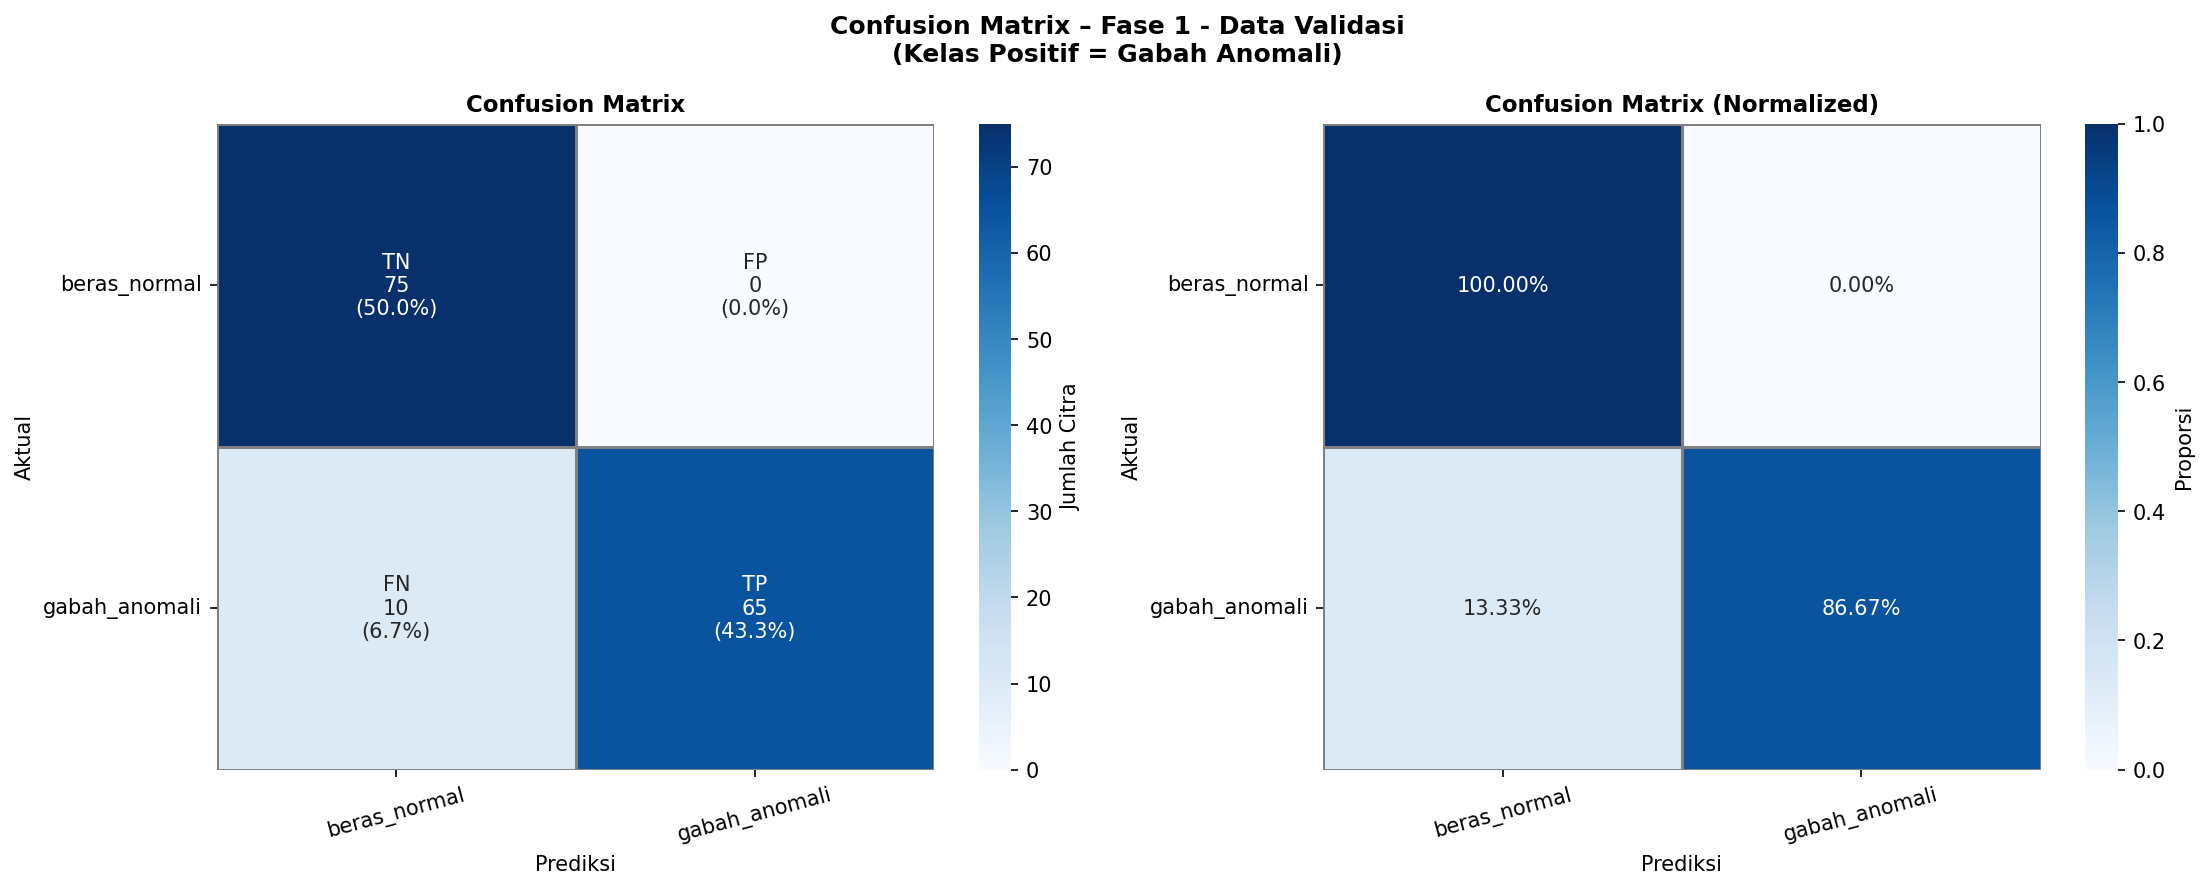


  Confusion Matrix Detail (Fase 1 - Data Validasi):
  TP (Gabah → Gabah)  : 65
  TN (Beras → Beras)  : 75
  FP (Beras → Gabah)  : 0  ← False Alarm
  FN (Gabah → Beras)  : 10  ← Miss Detection
   💾 Gambar disimpan: /content/drive/MyDrive/Hasil_Penelitian/plots/confusion_matrix_fase1_testing_20260314_050848.png


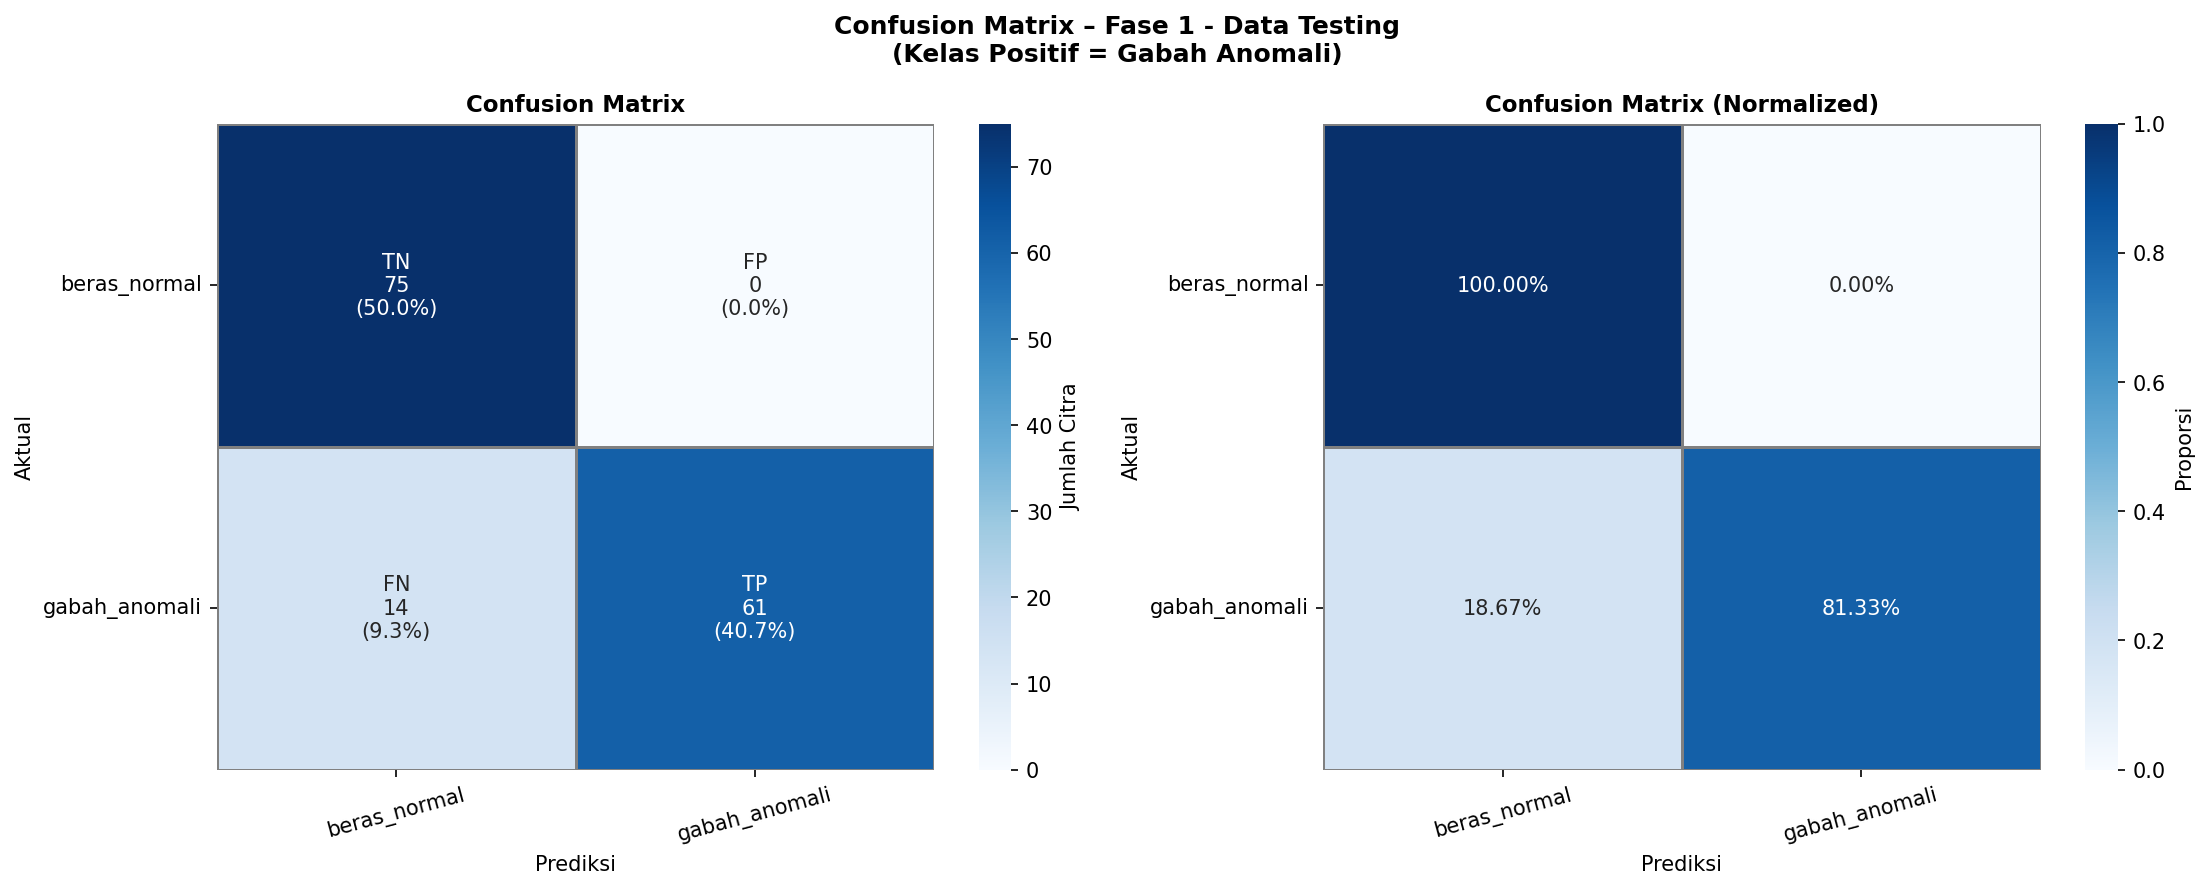


  Confusion Matrix Detail (Fase 1 - Data Testing):
  TP (Gabah → Gabah)  : 61
  TN (Beras → Beras)  : 75
  FP (Beras → Gabah)  : 0  ← False Alarm
  FN (Gabah → Beras)  : 14  ← Miss Detection
   💾 Laporan disimpan: /content/drive/MyDrive/Hasil_Penelitian/reports/laporan_evaluasi_fase1_20260314_050848.txt

LAPORAN EVALUASI FASE 1 (Transfer Learning - Frozen Base)
Run: 20260314_050848

HASIL EVALUASI – DATA VALIDASI:
- Accuracy         : 0.9333  (93.33%)
- Precision (macro): 0.9412
- Recall    (macro): 0.9333
- F1-Score  (macro): 0.9330
- TP: 65 | TN: 75 | FP: 0 | FN: 10

Classification Report – Validasi:
               precision    recall  f1-score   support

 beras_normal       0.88      1.00      0.94        75
gabah_anomali       1.00      0.87      0.93        75

     accuracy                           0.93       150
    macro avg       0.94      0.93      0.93       150
 weighted avg       0.94      0.93      0.93       150


HASIL EVALUASI – DATA TESTING:
- Accuracy         : 0.9

In [33]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SEL 10B – Evaluasi Confusion Matrix & Metrik FASE 1   ║
# ╚══════════════════════════════════════════════════════════╝

print("\n" + "="*50)
print("📊 EVALUASI MODEL FASE 1 (Transfer Learning)")
print("="*50)

# Pastikan bobot fase 1 yang aktif
model.load_weights(MODEL_PHASE1_PATH)

# ── Prediksi ──────────────────────────────────────────────────
print("\n📌 Prediksi Data Validasi (Fase 1)...")
y_true_val_p1, y_pred_val_p1, y_proba_val_p1 = predict_dataset(
    model, val_ds, val_labels_np)

print("\n📌 Prediksi Data Testing (Fase 1)...")
y_true_test_p1, y_pred_test_p1, y_proba_test_p1 = predict_dataset(
    model, test_ds, test_labels_np)

# ── Metrik ────────────────────────────────────────────────────
metrics_val_p1  = compute_metrics_balanced(
    y_true_val_p1,  y_pred_val_p1,  y_proba_val_p1,  'Fase 1 - Validasi')
metrics_test_p1 = compute_metrics_balanced(
    y_true_test_p1, y_pred_test_p1, y_proba_test_p1, 'Fase 1 - Testing')

# ── Confusion Matrix ──────────────────────────────────────────
cm_val_p1,  TP_v1, TN_v1, FP_v1, FN_v1 = plot_confusion_matrix_balanced(
    y_true_val_p1,  y_pred_val_p1,
    'Fase 1 - Data Validasi',
    'confusion_matrix_fase1_validasi'
)
cm_test_p1, TP_t1, TN_t1, FP_t1, FN_t1 = plot_confusion_matrix_balanced(
    y_true_test_p1, y_pred_test_p1,
    'Fase 1 - Data Testing',
    'confusion_matrix_fase1_testing'
)

# ── Simpan laporan ────────────────────────────────────────────
from sklearn.metrics import classification_report

report_p1 = f"""
LAPORAN EVALUASI FASE 1 (Transfer Learning - Frozen Base)
Run: {RUN_TIMESTAMP}
{'='*60}

HASIL EVALUASI – DATA VALIDASI:
- Accuracy         : {metrics_val_p1['accuracy']:.4f}  ({metrics_val_p1['accuracy']*100:.2f}%)
- Precision (macro): {metrics_val_p1['precision_macro']:.4f}
- Recall    (macro): {metrics_val_p1['recall_macro']:.4f}
- F1-Score  (macro): {metrics_val_p1['f1_macro']:.4f}
- TP: {TP_v1} | TN: {TN_v1} | FP: {FP_v1} | FN: {FN_v1}

Classification Report – Validasi:
{classification_report(y_true_val_p1, y_pred_val_p1, target_names=CLASS_NAMES)}

HASIL EVALUASI – DATA TESTING:
- Accuracy         : {metrics_test_p1['accuracy']:.4f}  ({metrics_test_p1['accuracy']*100:.2f}%)
- Precision (macro): {metrics_test_p1['precision_macro']:.4f}
- Recall    (macro): {metrics_test_p1['recall_macro']:.4f}
- F1-Score  (macro): {metrics_test_p1['f1_macro']:.4f}
- TP: {TP_t1} | TN: {TN_t1} | FP: {FP_t1} | FN: {FN_t1}

Classification Report – Testing:
{classification_report(y_true_test_p1, y_pred_test_p1, target_names=CLASS_NAMES)}
"""
save_report(report_p1, 'laporan_evaluasi_fase1')
print(report_p1)

In [11]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SEL 11: TRAINING FASE 2 - FINE TUNING                   ║
# ╚══════════════════════════════════════════════════════════╝

print("\n" + "="*50)
print("🔧 FASE 2: FINE-TUNING (Buka 30 Lapisan Terakhir)")
print("="*50)

if os.path.exists(MODEL_PHASE2_PATH):
    print(f"✅ Model Fase 2 ditemukan: {MODEL_PHASE2_PATH}")
    print("   Load model (tidak re-train)...")
    model, base_model = build_model_phase1()
    model = build_model_phase2(model, base_model)
    model.load_weights(MODEL_PHASE2_PATH)
    print("   ✅ Model Fase 2 berhasil di-load!")

else:
    print("🔄 Model Fase 2 belum ada. Mulai fine-tuning...")

    # Load bobot terbaik fase 1
    if os.path.exists(MODEL_PHASE1_PATH):
        model.load_weights(MODEL_PHASE1_PATH)
        print("   Bobot Fase 1 di-load sebagai starting point.")
    else:
        print("   ⚠️ Model Fase 1 tidak ditemukan, fine-tune dari bobot saat ini.")

    model = build_model_phase2(model, base_model)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LR_PHASE2),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )

    callbacks_p2 = [
        # ── FIX: ekstensi wajib .weights.h5 ─────────────────
        ModelCheckpoint(
            MODEL_PHASE2_PATH,
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        ),
        EarlyStopping(
            monitor='val_accuracy',
            patience=7,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=3,
            min_lr=1e-8,
            verbose=1
        )
    ]

    print(f"\n   Fine-tuning selama maksimal {EPOCHS_PHASE2} epoch...")
    hist_p2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_PHASE2,
        callbacks=callbacks_p2,
        verbose=1
    )
    history_all['phase2'] = hist_p2.history

    # Update history JSON
    if os.path.exists(HISTORY_PATH):
        with open(HISTORY_PATH, 'r') as f:
            existing = json.load(f)
    else:
        existing = {}

    existing['phase2'] = {k: [float(v) for v in vals]
                          for k, vals in hist_p2.history.items()}
    with open(HISTORY_PATH, 'w') as f:
        json.dump(existing, f)

    # Simpan model final format .keras (Keras baru)
    model.save(MODEL_FINAL_PATH)
    print(f"\n✅ Model Fase 2 tersimpan : {MODEL_PHASE2_PATH}")
    print(f"✅ Model Final tersimpan  : {MODEL_FINAL_PATH}")


🔧 FASE 2: FINE-TUNING (Buka 30 Lapisan Terakhir)
✅ Model Fase 2 ditemukan: /content/drive/MyDrive/Hasil_Penelitian/model/model_phase2_best.weights.h5
   Load model (tidak re-train)...
   Lapisan trainable setelah fine-tune: 8
   ✅ Model Fase 2 berhasil di-load!



📊 EVALUASI MODEL FASE 2 (Fine-Tuning)

📌 Prediksi Data Validasi...
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step

📌 Prediksi Data Testing...
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step

  HASIL EVALUASI – FASE 2 - VALIDASI
  Accuracy         : 0.9200  (92.00%)
  Precision (macro): 0.9310
  Recall    (macro): 0.9200
  F1-Score  (macro): 0.9195

  Detail Per Kelas:
  Kelas               Precision     Recall   F1-Score
  --------------------------------------------------
  beras_normal           0.8621     1.0000     0.9259
  gabah_anomali          1.0000     0.8400     0.9130

  HASIL EVALUASI – FASE 2 - TESTING
  Accuracy         : 0.9067  (90.67%)
  Precision (macro): 0.9213
  Recall    (macro): 0.9067
  F1-Score  (macro): 0.9058

  Detail Per Kelas:
  Kelas               Precision     Recall   F1-Score
  --------------------------------------------------
  beras_normal           0.8427     1.0000     0.9146
  gabah_anomali          1.0000     0.8133     0.8971
   💾 Gambar disimpan: /content/drive/MyD

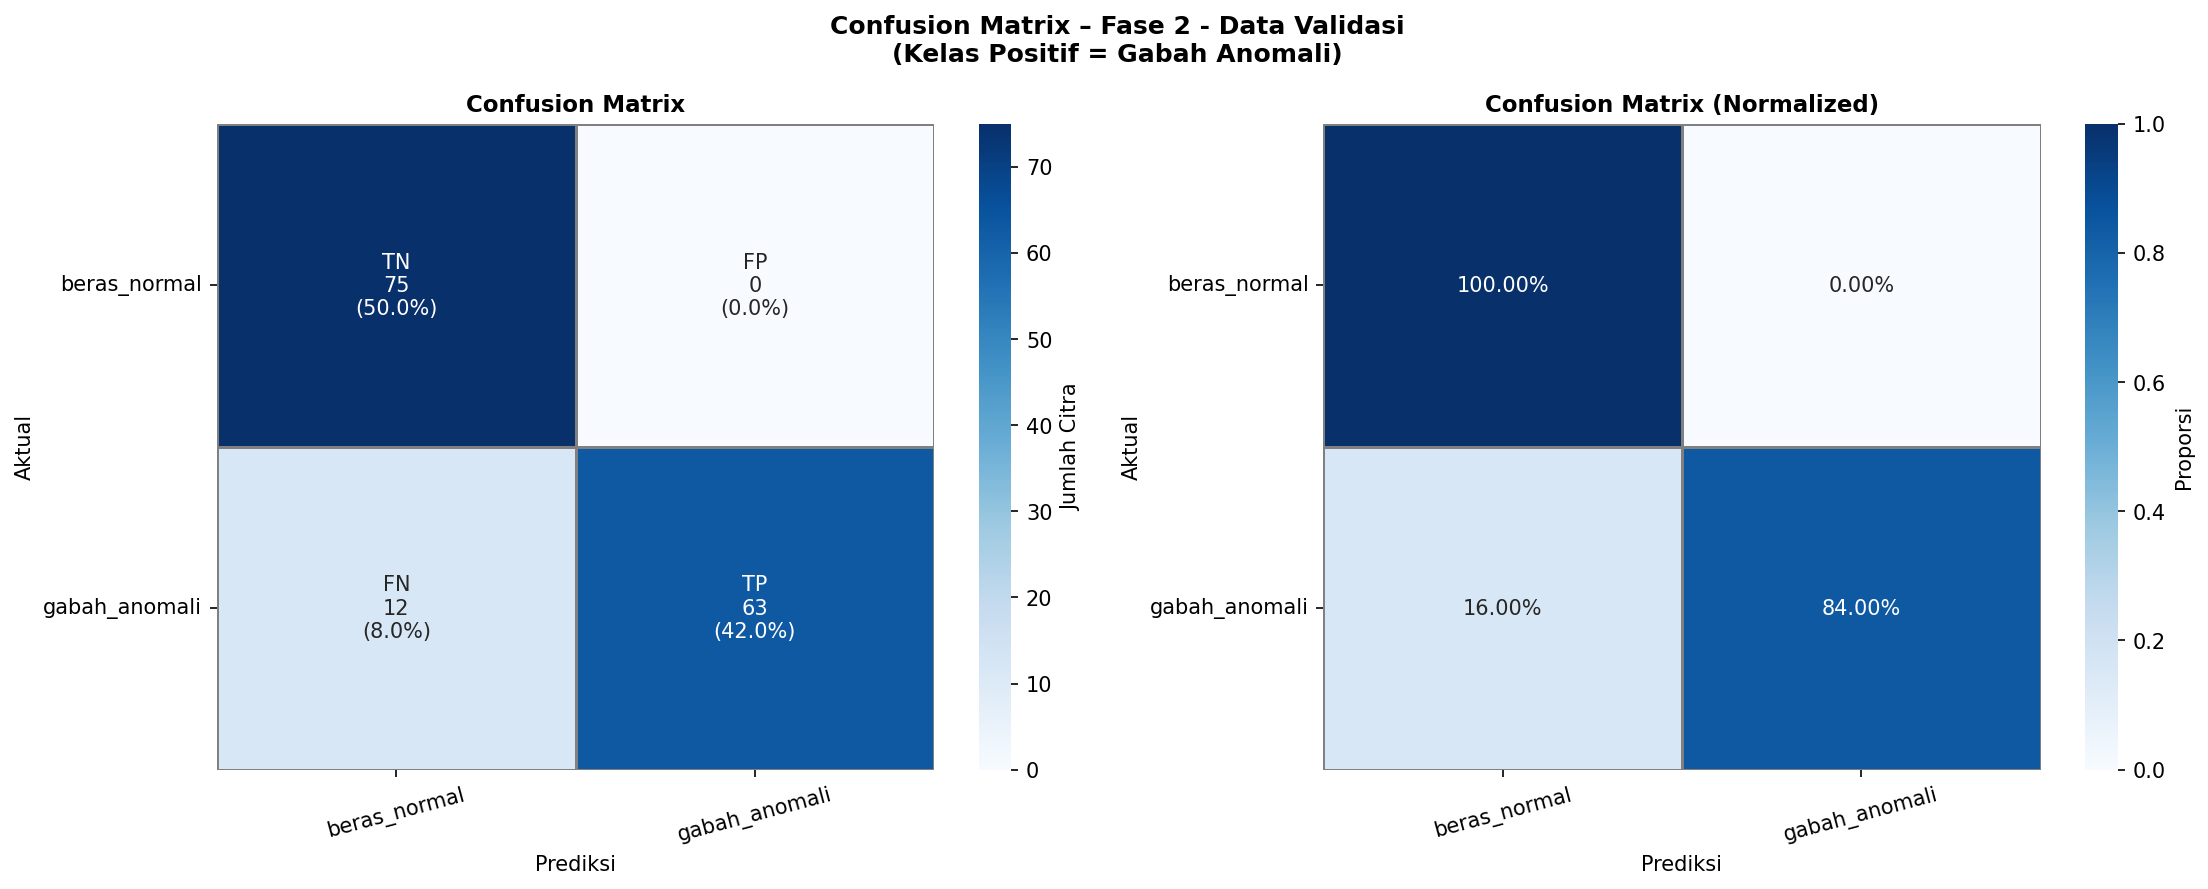


  Confusion Matrix Detail (Fase 2 - Data Validasi):
  TP (Gabah → Gabah)  : 63
  TN (Beras → Beras)  : 75
  FP (Beras → Gabah)  : 0  ← False Alarm
  FN (Gabah → Beras)  : 12  ← Miss Detection
   💾 Gambar disimpan: /content/drive/MyDrive/Hasil_Penelitian/plots/confusion_matrix_fase2_testing_20260314_050848.png


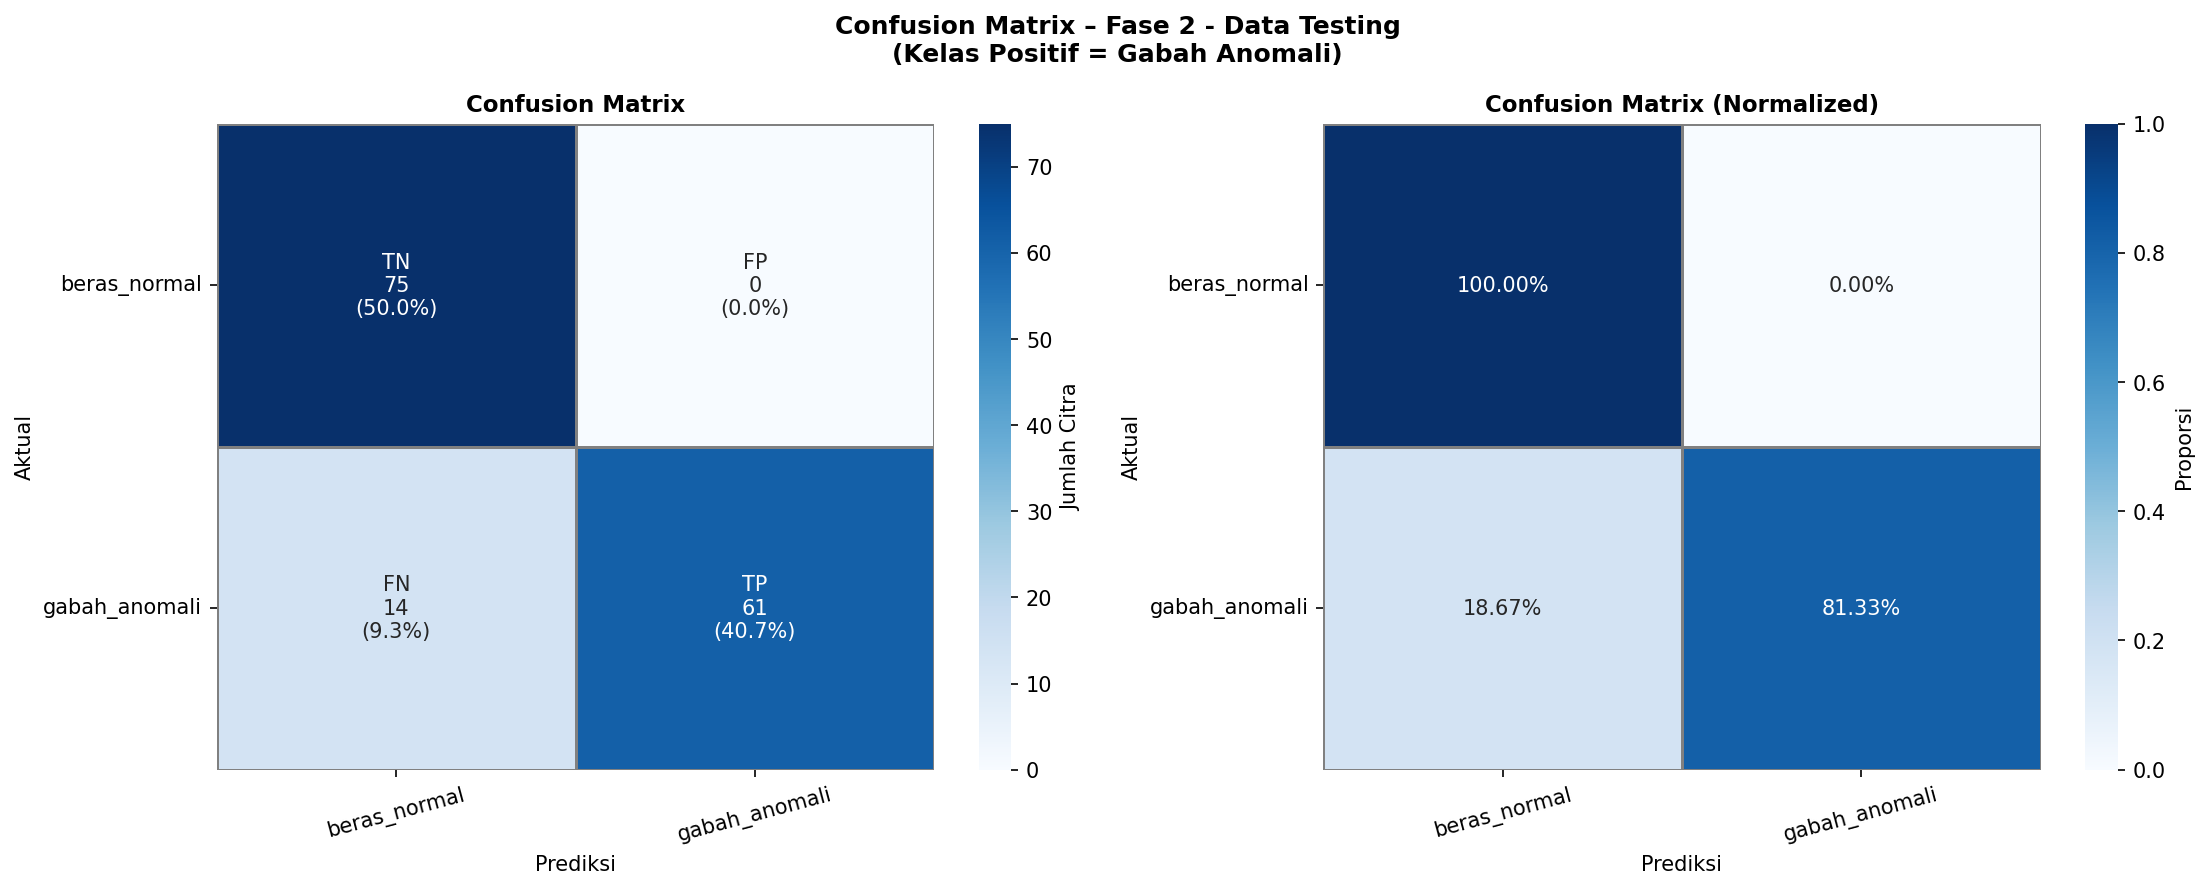


  Confusion Matrix Detail (Fase 2 - Data Testing):
  TP (Gabah → Gabah)  : 61
  TN (Beras → Beras)  : 75
  FP (Beras → Gabah)  : 0  ← False Alarm
  FN (Gabah → Beras)  : 14  ← Miss Detection
   💾 Laporan disimpan: /content/drive/MyDrive/Hasil_Penelitian/reports/laporan_evaluasi_fase2_20260314_050848.txt

LAPORAN EVALUASI FASE 2 (Fine-Tuning – 30 Lapisan Terakhir Dibuka)
Run: 20260314_050848

HASIL EVALUASI – DATA VALIDASI:
- Accuracy         : 0.9200  (92.00%)
- Precision (macro): 0.9310
- Recall    (macro): 0.9200
- F1-Score  (macro): 0.9195
- TP: 63 | TN: 75 | FP: 0 | FN: 12

Classification Report – Validasi:
               precision    recall  f1-score   support

 beras_normal       0.86      1.00      0.93        75
gabah_anomali       1.00      0.84      0.91        75

     accuracy                           0.92       150
    macro avg       0.93      0.92      0.92       150
 weighted avg       0.93      0.92      0.92       150


HASIL EVALUASI – DATA TESTING:
- Accuracy     

In [30]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SEL 11B – Evaluasi Confusion Matrix & Metrik Fase 2   ║
# ╚══════════════════════════════════════════════════════════╝

print("\n" + "="*50)
print("📊 EVALUASI MODEL FASE 2 (Fine-Tuning)")
print("="*50)

# ── Prediksi pada data validasi dan testing ───────────────────
print("\n📌 Prediksi Data Validasi...")
y_true_val, y_pred_val, y_proba_val = predict_dataset(model, val_ds, val_labels_np)

print("\n📌 Prediksi Data Testing...")
y_true_test, y_pred_test, y_proba_test = predict_dataset(model, test_ds, test_labels_np)

# ── Hitung metrik ─────────────────────────────────────────────
metrics_val  = compute_metrics_balanced(y_true_val,  y_pred_val,  y_proba_val,  'Fase 2 - Validasi')
metrics_test = compute_metrics_balanced(y_true_test, y_pred_test, y_proba_test, 'Fase 2 - Testing')

# ── Plot confusion matrix ─────────────────────────────────────
cm_val,  TP_v, TN_v, FP_v, FN_v = plot_confusion_matrix_balanced(
    y_true_val,  y_pred_val,
    'Fase 2 - Data Validasi',
    'confusion_matrix_fase2_validasi'
)
cm_test, TP_t, TN_t, FP_t, FN_t = plot_confusion_matrix_balanced(
    y_true_test, y_pred_test,
    'Fase 2 - Data Testing',
    'confusion_matrix_fase2_testing'
)

# ── Simpan laporan ────────────────────────────────────────────
from sklearn.metrics import classification_report

report_p2 = f"""
LAPORAN EVALUASI FASE 2 (Fine-Tuning – 30 Lapisan Terakhir Dibuka)
Run: {RUN_TIMESTAMP}
{'='*60}

HASIL EVALUASI – DATA VALIDASI:
- Accuracy         : {metrics_val['accuracy']:.4f}  ({metrics_val['accuracy']*100:.2f}%)
- Precision (macro): {metrics_val['precision_macro']:.4f}
- Recall    (macro): {metrics_val['recall_macro']:.4f}
- F1-Score  (macro): {metrics_val['f1_macro']:.4f}
- TP: {TP_v} | TN: {TN_v} | FP: {FP_v} | FN: {FN_v}

Classification Report – Validasi:
{classification_report(y_true_val, y_pred_val, target_names=CLASS_NAMES)}

HASIL EVALUASI – DATA TESTING:
- Accuracy         : {metrics_test['accuracy']:.4f}  ({metrics_test['accuracy']*100:.2f}%)
- Precision (macro): {metrics_test['precision_macro']:.4f}
- Recall    (macro): {metrics_test['recall_macro']:.4f}
- F1-Score  (macro): {metrics_test['f1_macro']:.4f}
- TP: {TP_t} | TN: {TN_t} | FP: {FP_t} | FN: {FN_t}

Classification Report – Testing:
{classification_report(y_true_test, y_pred_test, target_names=CLASS_NAMES)}
"""
save_report(report_p2, 'laporan_evaluasi_fase2')
print(report_p2)


📊 TABEL PERBANDINGAN FASE 1 vs FASE 2

  DATA TESTING:
  Metrik                     Fase 1     Fase 2    Selisih    Ket
  ----------------------------------------------------------
  Accuracy                   0.9067     0.9067    +0.0000 = Sama
  Precision (macro)          0.9213     0.9213    +0.0000 = Sama
  Recall (macro)             0.9067     0.9067    +0.0000 = Sama
  F1-Score (macro)           0.9058     0.9058    +0.0000 = Sama
  ----------------------------------------------------------

  DATA VALIDASI:
  Metrik                     Fase 1     Fase 2    Selisih    Ket
  ----------------------------------------------------------
  Accuracy                   0.9333     0.9200    -0.0133 ↓ Turun
  Precision (macro)          0.9412     0.9310    -0.0101 ↓ Turun
  Recall (macro)             0.9333     0.9200    -0.0133 ↓ Turun
  F1-Score (macro)           0.9330     0.9195    -0.0136 ↓ Turun
  ----------------------------------------------------------
   💾 Gambar disimpan: /conte

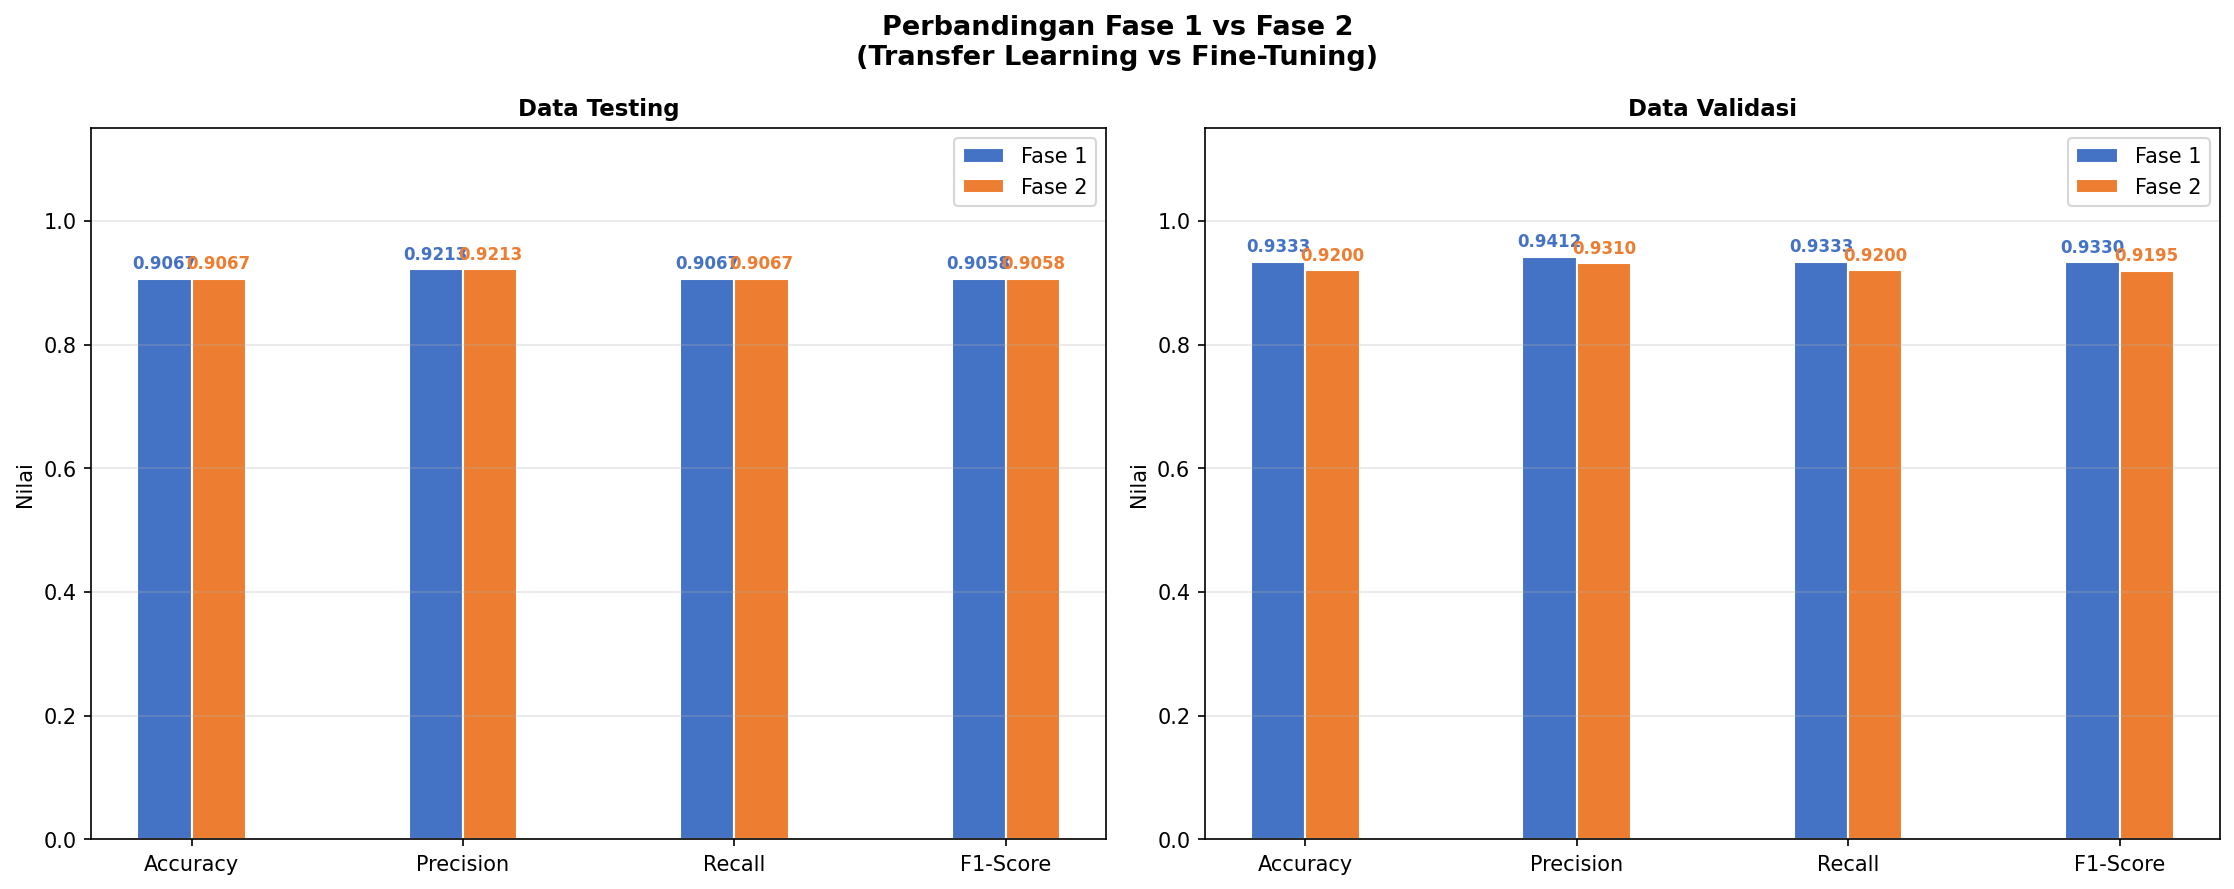

   💾 Laporan disimpan: /content/drive/MyDrive/Hasil_Penelitian/reports/perbandingan_fase1_vs_fase2_20260314_050848.txt

LAPORAN PERBANDINGAN FASE 1 vs FASE 2
Run: 20260314_050848

DATA TESTING:
Metrik                     Fase 1     Fase 2    Selisih
-------------------------------------------------------
Accuracy                   0.9067     0.9067    +0.0000
Precision (macro)          0.9213     0.9213    +0.0000
Recall (macro)             0.9067     0.9067    +0.0000
F1-Score (macro)           0.9058     0.9058    +0.0000

DATA VALIDASI:
Metrik                     Fase 1     Fase 2    Selisih
-------------------------------------------------------
Accuracy                   0.9333     0.9200    -0.0133
Precision (macro)          0.9412     0.9310    -0.0101
Recall (macro)             0.9333     0.9200    -0.0133
F1-Score (macro)           0.9330     0.9195    -0.0136

CONFUSION MATRIX RINGKASAN:
             Fase 1 Testing    Fase 2 Testing
TP         : 61                 61
TN      

In [34]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SEL 11C – Tabel Perbandingan Fase 1 vs Fase 2         ║
# ╚══════════════════════════════════════════════════════════╝

print("\n" + "="*60)
print("📊 TABEL PERBANDINGAN FASE 1 vs FASE 2")
print("="*60)

# ── Tabel di terminal ─────────────────────────────────────────
metrics_list = [
    ('Accuracy',         'accuracy'),
    ('Precision (macro)','precision_macro'),
    ('Recall (macro)',   'recall_macro'),
    ('F1-Score (macro)', 'f1_macro'),
]

print(f"\n  DATA TESTING:")
print(f"  {'Metrik':<22} {'Fase 1':>10} {'Fase 2':>10} {'Selisih':>10} {'Ket':>6}")
print(f"  {'-'*58}")

for label, key in metrics_list:
    v1   = metrics_test_p1[key]
    v2   = metrics_test[key]
    diff = v2 - v1
    if diff > 0:
        arrow = '↑ Naik'
    elif diff < 0:
        arrow = '↓ Turun'
    else:
        arrow = '= Sama'
    print(f"  {label:<22} {v1:>10.4f} {v2:>10.4f} {diff:>+10.4f} {arrow:>6}")

print(f"  {'-'*58}")

print(f"\n  DATA VALIDASI:")
print(f"  {'Metrik':<22} {'Fase 1':>10} {'Fase 2':>10} {'Selisih':>10} {'Ket':>6}")
print(f"  {'-'*58}")

for label, key in metrics_list:
    v1   = metrics_val_p1[key]
    v2   = metrics_val[key]
    diff = v2 - v1
    if diff > 0:
        arrow = '↑ Naik'
    elif diff < 0:
        arrow = '↓ Turun'
    else:
        arrow = '= Sama'
    print(f"  {label:<22} {v1:>10.4f} {v2:>10.4f} {diff:>+10.4f} {arrow:>6}")

print(f"  {'-'*58}")

# ── Visualisasi bar chart perbandingan ────────────────────────
labels_chart = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
keys_chart   = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

fase1_test = [metrics_test_p1[k] for k in keys_chart]
fase2_test = [metrics_test[k]    for k in keys_chart]
fase1_val  = [metrics_val_p1[k]  for k in keys_chart]
fase2_val  = [metrics_val[k]     for k in keys_chart]

x     = np.arange(len(labels_chart))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Perbandingan Fase 1 vs Fase 2\n(Transfer Learning vs Fine-Tuning)',
             fontsize=13, fontweight='bold')

# ── Subplot kiri: Data Testing ────────────────────────────────
bars1 = axes[0].bar(x - width/2, fase1_test, width, label='Fase 1',
                    color='#4472C4', edgecolor='white')
bars2 = axes[0].bar(x + width/2, fase2_test, width, label='Fase 2',
                    color='#ED7D31', edgecolor='white')
axes[0].set_title('Data Testing', fontsize=11, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_chart)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Nilai')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
# Tambahkan nilai di atas bar
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.4f}', ha='center', va='bottom',
                 fontsize=8, color='#4472C4', fontweight='bold')
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.4f}', ha='center', va='bottom',
                 fontsize=8, color='#ED7D31', fontweight='bold')

# ── Subplot kanan: Data Validasi ──────────────────────────────
bars3 = axes[1].bar(x - width/2, fase1_val, width, label='Fase 1',
                    color='#4472C4', edgecolor='white')
bars4 = axes[1].bar(x + width/2, fase2_val, width, label='Fase 2',
                    color='#ED7D31', edgecolor='white')
axes[1].set_title('Data Validasi', fontsize=11, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_chart)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Nilai')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.4f}', ha='center', va='bottom',
                 fontsize=8, color='#4472C4', fontweight='bold')
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.4f}', ha='center', va='bottom',
                 fontsize=8, color='#ED7D31', fontweight='bold')

plt.tight_layout()
save_figure(fig, 'perbandingan_fase1_vs_fase2')

# ── Simpan laporan perbandingan ───────────────────────────────
report_comparison = f"""
LAPORAN PERBANDINGAN FASE 1 vs FASE 2
Run: {RUN_TIMESTAMP}
{'='*60}

DATA TESTING:
{'Metrik':<22} {'Fase 1':>10} {'Fase 2':>10} {'Selisih':>10}
{'-'*55}
"""
for label, key in metrics_list:
    v1   = metrics_test_p1[key]
    v2   = metrics_test[key]
    diff = v2 - v1
    report_comparison += f"{label:<22} {v1:>10.4f} {v2:>10.4f} {diff:>+10.4f}\n"

report_comparison += f"""
DATA VALIDASI:
{'Metrik':<22} {'Fase 1':>10} {'Fase 2':>10} {'Selisih':>10}
{'-'*55}
"""
for label, key in metrics_list:
    v1   = metrics_val_p1[key]
    v2   = metrics_val[key]
    diff = v2 - v1
    report_comparison += f"{label:<22} {v1:>10.4f} {v2:>10.4f} {diff:>+10.4f}\n"

report_comparison += f"""
CONFUSION MATRIX RINGKASAN:
{'='*60}
             Fase 1 Testing    Fase 2 Testing
TP         : {TP_t1:<18} {TP_t}
TN         : {TN_t1:<18} {TN_t}
FP         : {FP_t1:<18} {FP_t}
FN         : {FN_t1:<18} {FN_t}
"""
save_report(report_comparison, 'perbandingan_fase1_vs_fase2')
print(report_comparison)


📈 VISUALISASI LEARNING CURVES
   💾 Gambar disimpan: /content/drive/MyDrive/Hasil_Penelitian/plots/learning_curve_phase1_20260314_050848.png


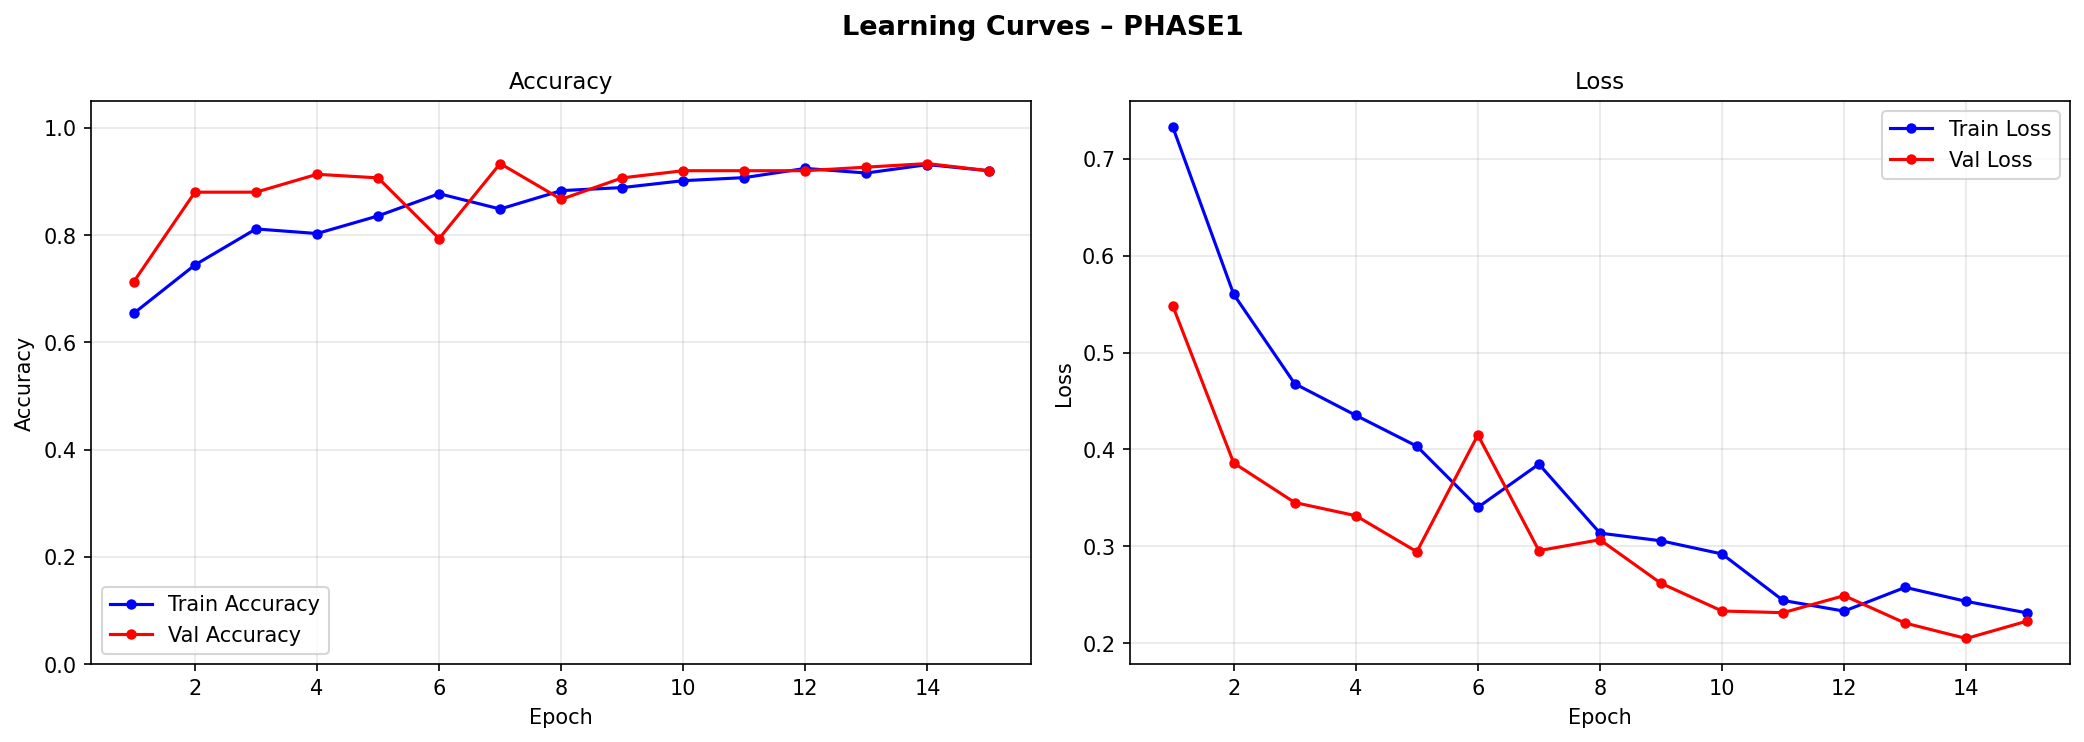

   💾 Gambar disimpan: /content/drive/MyDrive/Hasil_Penelitian/plots/learning_curve_phase2_20260314_050848.png


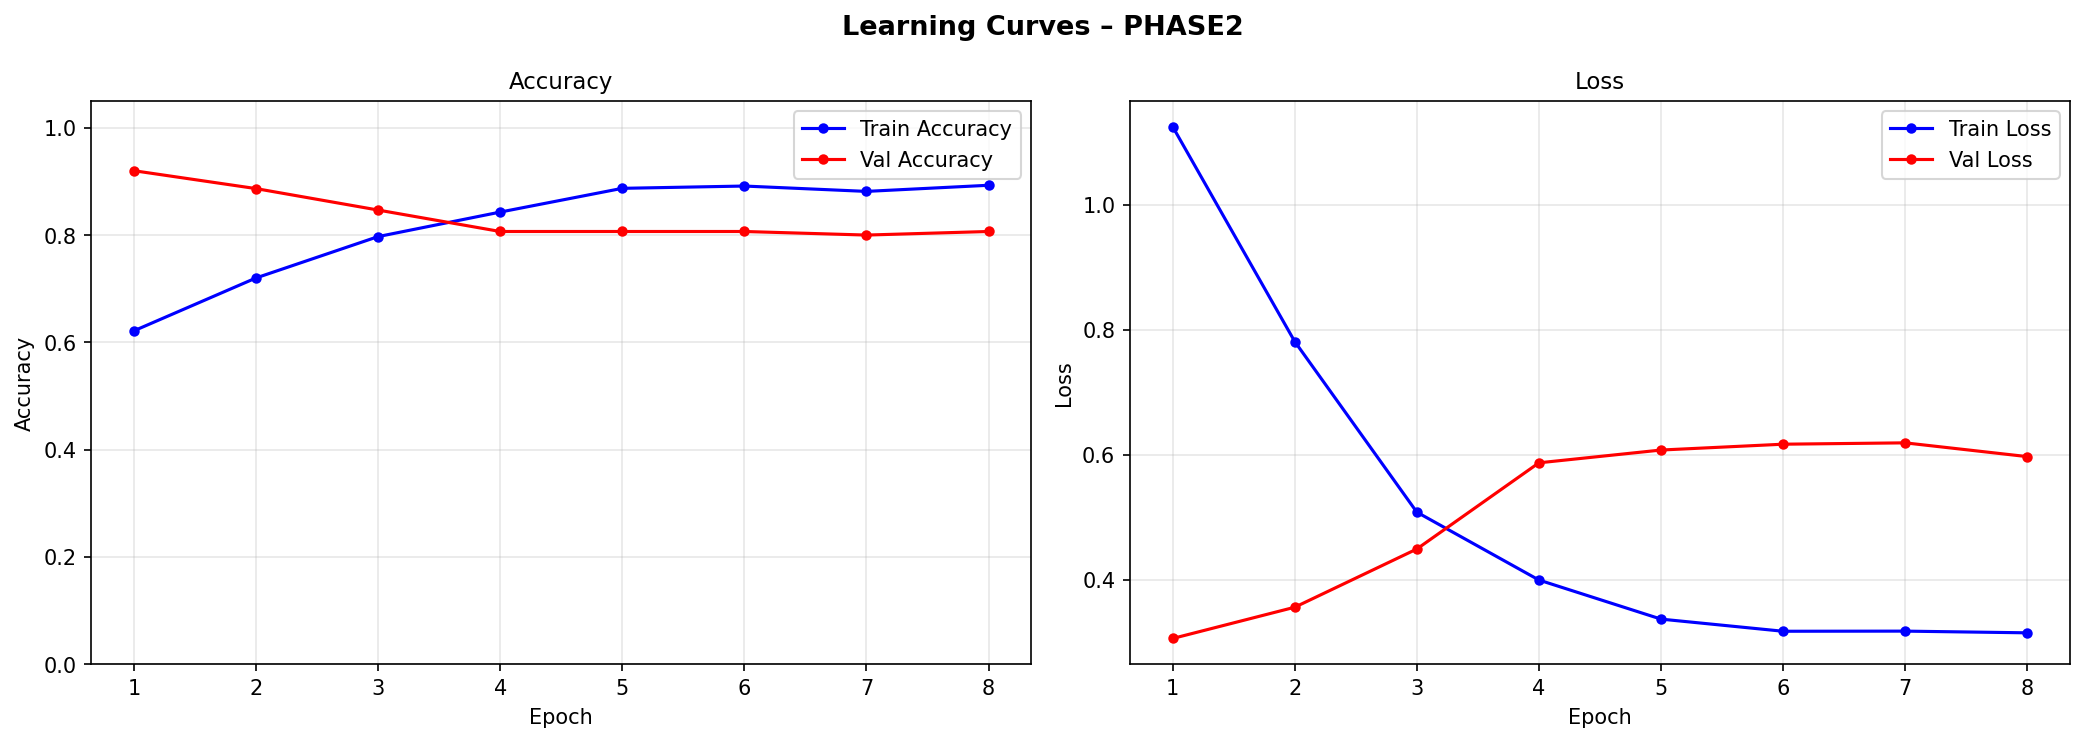

In [12]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SEL 12: LEARNING CURVES                                 ║
# ╚══════════════════════════════════════════════════════════╝

print("\n" + "="*50)
print("📈 VISUALISASI LEARNING CURVES")
print("="*50)

# Load history jika ada
if os.path.exists(HISTORY_PATH):
    with open(HISTORY_PATH, 'r') as f:
        history_all = json.load(f)

def plot_learning_curves(history_dict, phase_name, save_name):
    """Plot accuracy dan loss curves."""
    if phase_name not in history_dict:
        print(f"   ⚠️  History {phase_name} tidak ditemukan, lewati.")
        return

    hist = history_dict[phase_name]
    epochs = range(1, len(hist['accuracy']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Learning Curves – {phase_name.upper()}',
                 fontsize=13, fontweight='bold')

    # Accuracy
    axes[0].plot(epochs, hist['accuracy'],     'b-o', label='Train Accuracy',  markersize=4)
    axes[0].plot(epochs, hist['val_accuracy'], 'r-o', label='Val Accuracy',    markersize=4)
    axes[0].set_title('Accuracy', fontsize=11)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(0, 1.05)

    # Loss
    axes[1].plot(epochs, hist['loss'],     'b-o', label='Train Loss',  markersize=4)
    axes[1].plot(epochs, hist['val_loss'], 'r-o', label='Val Loss',    markersize=4)
    axes[1].set_title('Loss', fontsize=11)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    save_figure(fig, save_name)

plot_learning_curves(history_all, 'phase1', 'learning_curve_phase1')
plot_learning_curves(history_all, 'phase2', 'learning_curve_phase2')


📊 EVALUASI MODEL

📌 Evaluasi pada DATA VALIDASI:
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step

  HASIL EVALUASI – VALIDASI
  Accuracy         : 0.9200  (92.00%)
  Precision (macro): 0.9310
  Recall    (macro): 0.9200
  F1-Score  (macro): 0.9195

  Detail Per Kelas:
  Kelas               Precision     Recall   F1-Score
  --------------------------------------------------
  beras_normal           0.8621     1.0000     0.9259
  gabah_anomali          1.0000     0.8400     0.9130
   💾 Gambar disimpan: /content/drive/MyDrive/Hasil_Penelitian/plots/confusion_matrix_validasi_20260314_050848.png


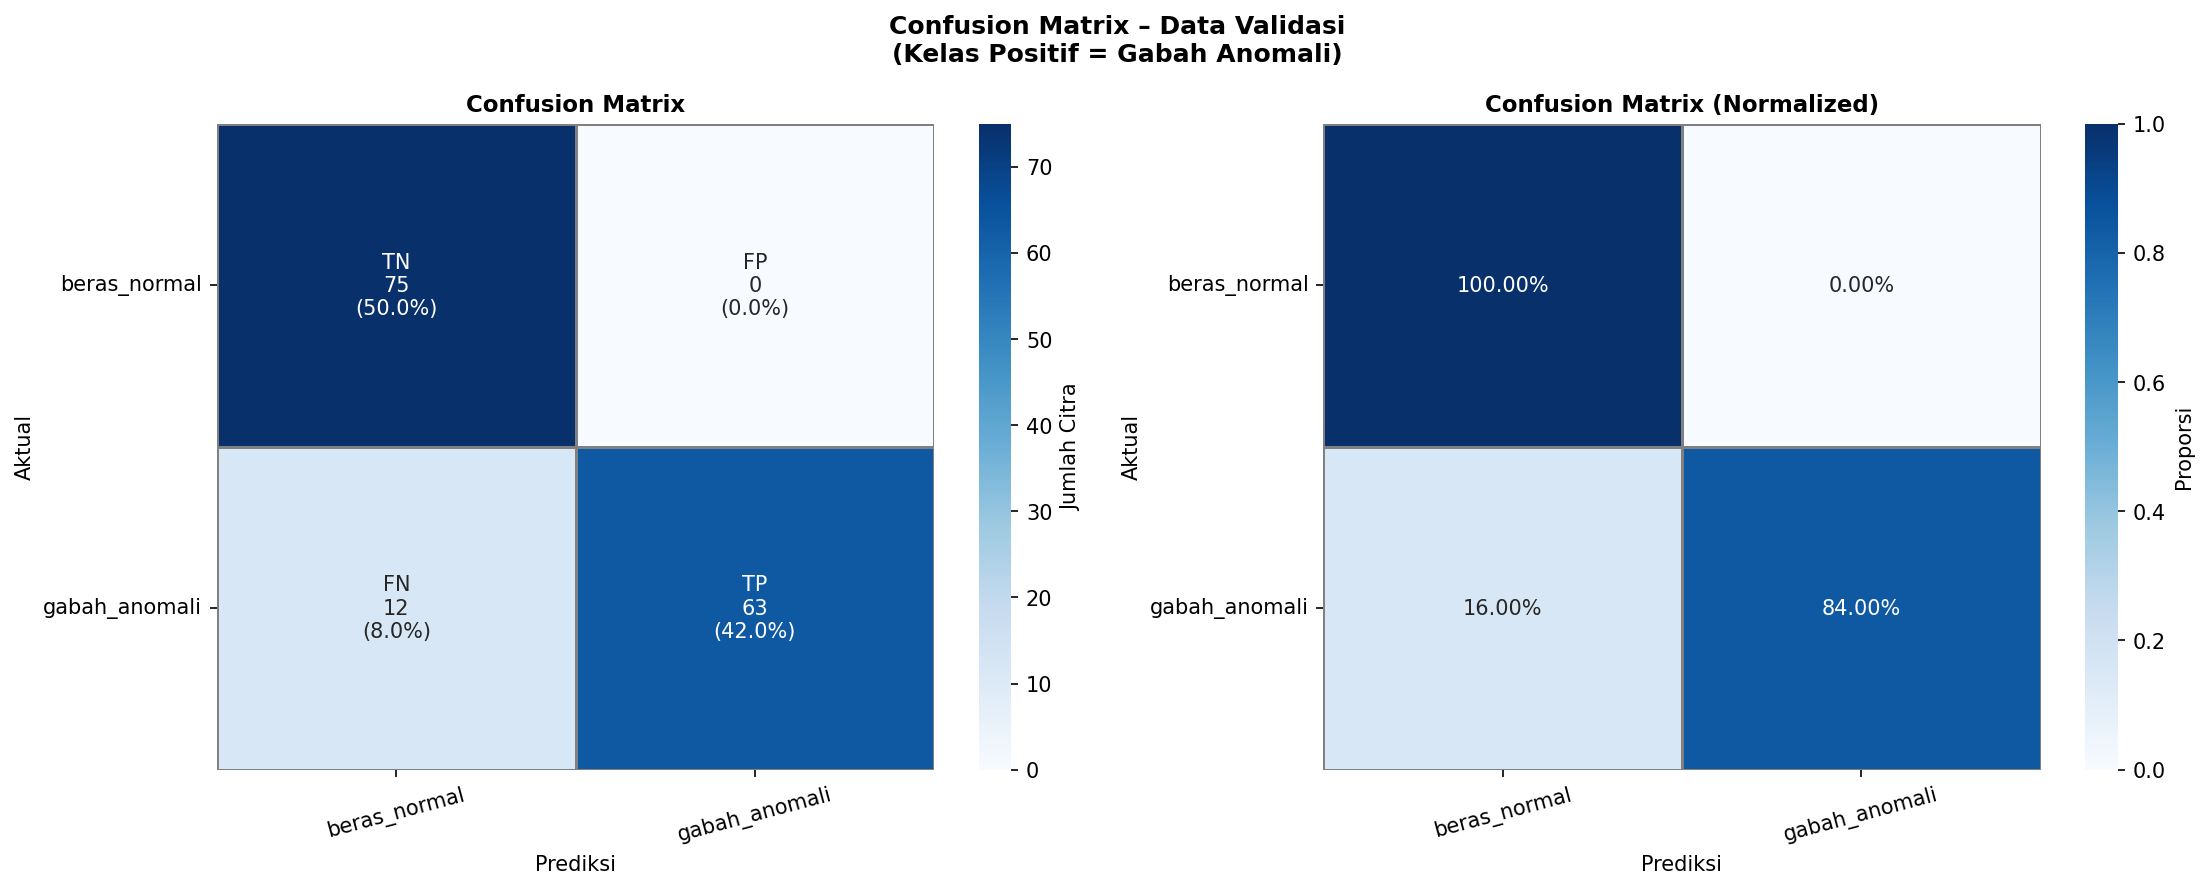


  Confusion Matrix Detail (Data Validasi):
  TP (Gabah → Gabah)  : 63
  TN (Beras → Beras)  : 75
  FP (Beras → Gabah)  : 0  ← False Alarm
  FN (Gabah → Beras)  : 12  ← Miss Detection

📌 Evaluasi pada DATA TESTING (Data Uji):
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step

  HASIL EVALUASI – TESTING
  Accuracy         : 0.9067  (90.67%)
  Precision (macro): 0.9213
  Recall    (macro): 0.9067
  F1-Score  (macro): 0.9058

  Detail Per Kelas:
  Kelas               Precision     Recall   F1-Score
  --------------------------------------------------
  beras_normal           0.8427     1.0000     0.9146
  gabah_anomali          1.0000     0.8133     0.8971
   💾 Gambar disimpan: /content/drive/MyDrive/Hasil_Penelitian/plots/confusion_matrix_testing_20260314_050848.png


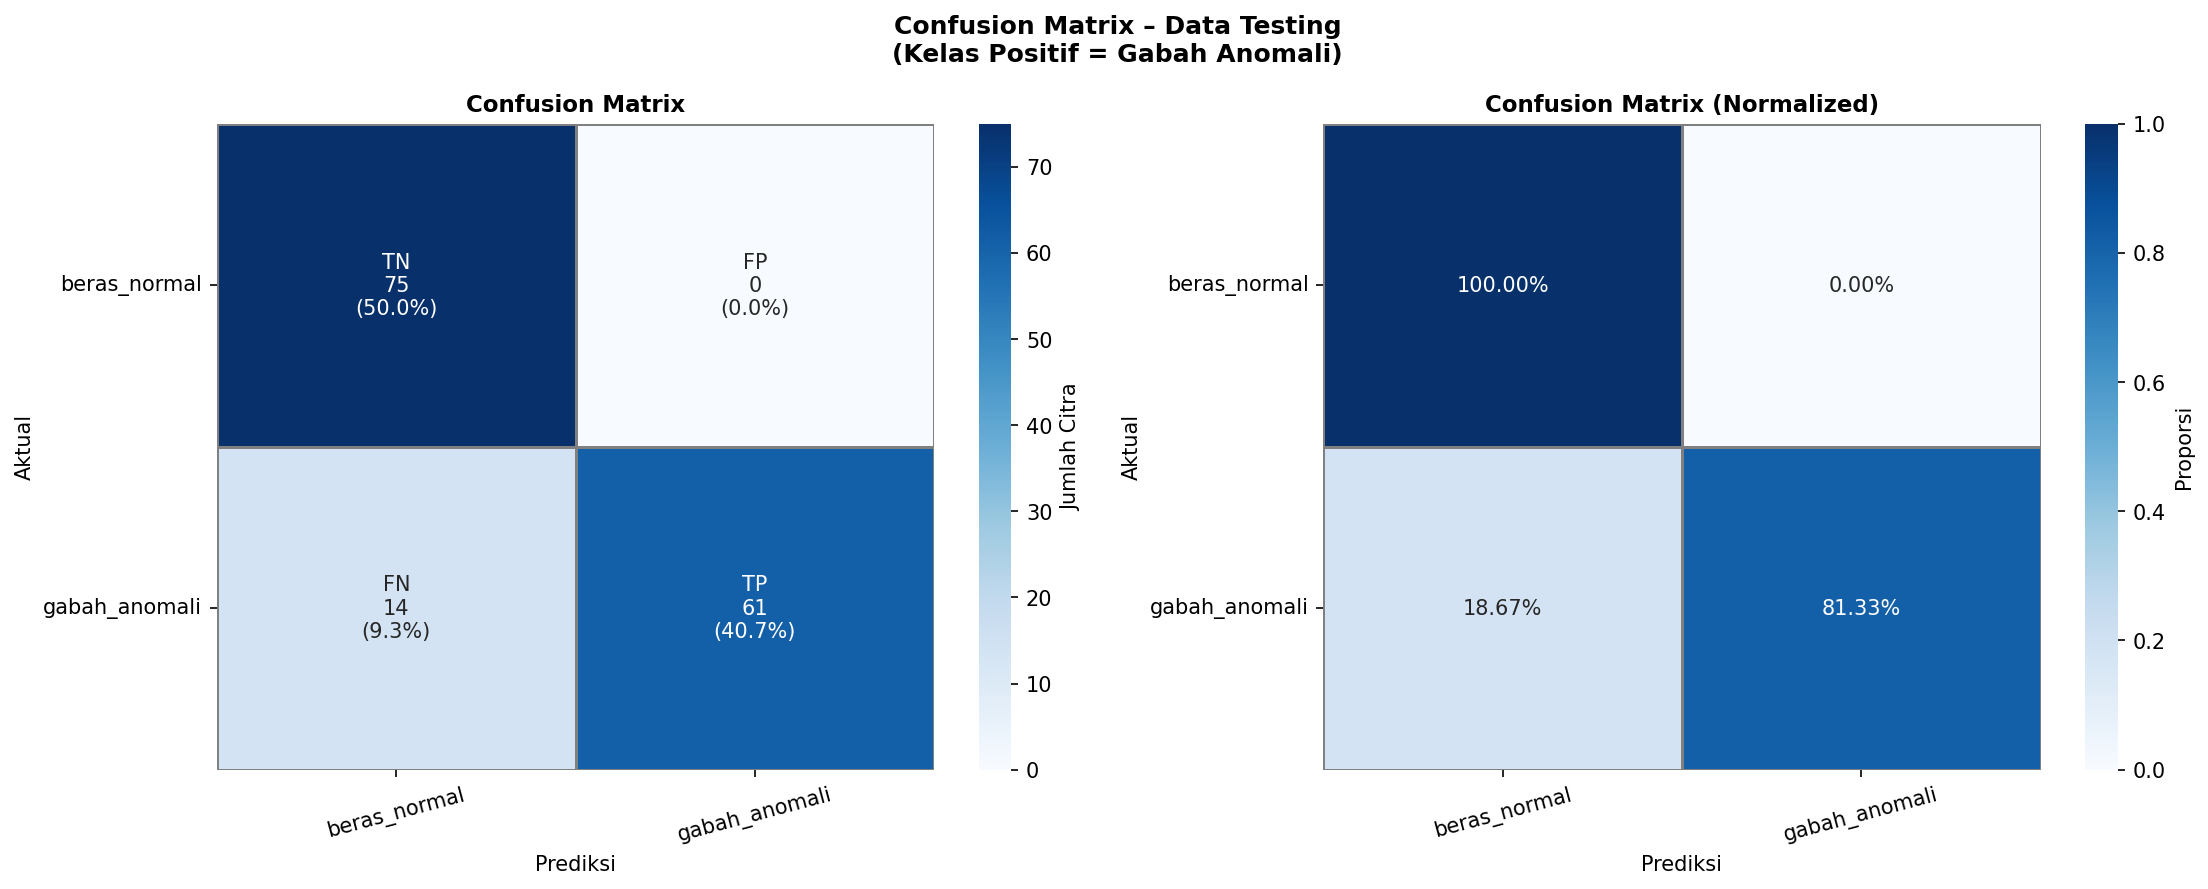


  Confusion Matrix Detail (Data Testing):
  TP (Gabah → Gabah)  : 61
  TN (Beras → Beras)  : 75
  FP (Beras → Gabah)  : 0  ← False Alarm
  FN (Gabah → Beras)  : 14  ← Miss Detection
   💾 Laporan disimpan: /content/drive/MyDrive/Hasil_Penelitian/reports/laporan_evaluasi_20260314_050848.txt


LAPORAN EVALUASI MODEL
Klasifikasi Gabah sebagai Anomali Visual pada Tumpukan Beras
CNN Berbasis MobileNetV2 | Transfer Learning + Fine-Tuning
Oleh: Barokah Saadah (NPM: 22010012)
Run Timestamp: 20260314_050848
 
KONFIGURASI MODEL:
- Arsitektur    : MobileNetV2 + Custom Head
- Input Size    : 224×224×3
- Fase 1        : Frozen base, LR=0.001, max 30 epoch
- Fase 2        : Fine-tune 30 lap terakhir, LR=1e-05, max 20 epoch
- Kelas Positif : gabah_anomali (index 1)
 
DATASET:
- Total       : 1000 citra
- Training    : 700 citra (70%)
- Validasi    : 150 citra (15%)
- Testing     : 150 citra (15%)
 
HASIL EVALUASI – DATA VALIDASI:
- Accuracy         : 0.9200 (92.00%)
- Precision (macro): 0.9310
- Reca

In [31]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SEL 13: EVALUASI MODEL – CONFUSION MATRIX & METRIK    ║
# ╚══════════════════════════════════════════════════════════╝

print("\n" + "="*50)
print("📊 EVALUASI MODEL")
print("="*50)

def predict_dataset(model, ds, true_labels):
    """Prediksi seluruh dataset, kembalikan y_true, y_pred, y_proba."""
    y_proba = model.predict(ds, verbose=1).flatten()
    y_pred  = (y_proba >= 0.5).astype(int)
    y_true  = np.array(true_labels)
    return y_true, y_pred, y_proba


def compute_metrics_balanced(y_true, y_pred, y_proba, set_name):
    """
    Hitung metrik dengan average='macro' agar hasilnya balance/sama
    antara kedua kelas (sesuai permintaan penelitian).
    Kelas positif = gabah_anomali (index 1)
    """
    # Metrics per-class dan macro
    acc  = accuracy_score(y_true, y_pred)
    prec_macro  = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_macro   = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro    = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # Per-class untuk tabel detail
    prec_per = precision_score(y_true, y_pred, average=None, zero_division=0)
    rec_per  = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1_per   = f1_score(y_true, y_pred, average=None, zero_division=0)

    print(f"\n{'='*55}")
    print(f"  HASIL EVALUASI – {set_name.upper()}")
    print(f"{'='*55}")
    print(f"  Accuracy         : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision (macro): {prec_macro:.4f}")
    print(f"  Recall    (macro): {rec_macro:.4f}")
    print(f"  F1-Score  (macro): {f1_macro:.4f}")
    print(f"\n  Detail Per Kelas:")
    print(f"  {'Kelas':<18} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
    print(f"  {'-'*50}")
    for i, cls in enumerate(CLASS_NAMES):
        print(f"  {cls:<18} {prec_per[i]:>10.4f} {rec_per[i]:>10.4f} {f1_per[i]:>10.4f}")
    print(f"{'='*55}")

    return {
        'set_name'      : set_name,
        'accuracy'      : acc,
        'precision_macro': prec_macro,
        'recall_macro'  : rec_macro,
        'f1_macro'      : f1_macro,
        'precision_per' : prec_per.tolist(),
        'recall_per'    : rec_per.tolist(),
        'f1_per'        : f1_per.tolist(),
    }


def plot_confusion_matrix_balanced(y_true, y_pred, set_name, save_name):
    """
    Plot confusion matrix dengan label TP, TN, FP, FN yang seimbang.
    Positif = gabah_anomali (sesuai Bab III.12 proposal).
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    # cm[i][j] = actual i, pred j
    # TN = cm[0][0], FP = cm[0][1]
    # FN = cm[1][0], TP = cm[1][1]
    TN, FP = cm[0][0], cm[0][1]
    FN, TP = cm[1][0], cm[1][1]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Confusion Matrix – {set_name}\n'
                 f'(Kelas Positif = Gabah Anomali)',
                 fontsize=12, fontweight='bold')

    # ── Kiri: Confusion Matrix dengan angka ──
    group_labels  = [f'TN\n{TN}', f'FP\n{FP}', f'FN\n{FN}', f'TP\n{TP}']
    group_pct     = [f'({v/cm.sum()*100:.1f}%)' for v in cm.flatten()]
    annot = np.array([f'{l}\n{p}' for l, p in zip(group_labels, group_pct)]).reshape(2, 2)

    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, linecolor='gray',
                cbar_kws={'label': 'Jumlah Citra'},
                ax=axes[0])
    axes[0].set_title('Confusion Matrix', fontsize=11, fontweight='bold')
    axes[0].set_xlabel('Prediksi', fontsize=10)
    axes[0].set_ylabel('Aktual', fontsize=10)
    axes[0].tick_params(axis='x', rotation=15)
    axes[0].tick_params(axis='y', rotation=0)

    # ── Kanan: Normalized Confusion Matrix (per-row) ──
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    annot_norm = np.array([f'{v:.2%}' for v in cm_norm.flatten()]).reshape(2, 2)
    sns.heatmap(cm_norm, annot=annot_norm, fmt='', cmap='Blues',
                vmin=0, vmax=1,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, linecolor='gray',
                cbar_kws={'label': 'Proporsi'},
                ax=axes[1])
    axes[1].set_title('Confusion Matrix (Normalized)', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Prediksi', fontsize=10)
    axes[1].set_ylabel('Aktual', fontsize=10)
    axes[1].tick_params(axis='x', rotation=15)
    axes[1].tick_params(axis='y', rotation=0)

    plt.tight_layout()
    save_figure(fig, save_name)

    # Print ringkasan TP/TN/FP/FN
    print(f"\n  Confusion Matrix Detail ({set_name}):")
    print(f"  TP (Gabah → Gabah)  : {TP}")
    print(f"  TN (Beras → Beras)  : {TN}")
    print(f"  FP (Beras → Gabah)  : {FP}  ← False Alarm")
    print(f"  FN (Gabah → Beras)  : {FN}  ← Miss Detection")

    return cm, TP, TN, FP, FN


# ─── Evaluasi pada Validasi ───────────────────────────────────
print("\n📌 Evaluasi pada DATA VALIDASI:")
y_true_val, y_pred_val, y_proba_val = predict_dataset(model, val_ds, val_labels_np)
metrics_val = compute_metrics_balanced(y_true_val, y_pred_val, y_proba_val, 'Validasi')
cm_val, TP_v, TN_v, FP_v, FN_v = plot_confusion_matrix_balanced(
    y_true_val, y_pred_val, 'Data Validasi', 'confusion_matrix_validasi'
)

# ─── Evaluasi pada Testing ────────────────────────────────────
print("\n📌 Evaluasi pada DATA TESTING (Data Uji):")
y_true_test, y_pred_test, y_proba_test = predict_dataset(model, test_ds, test_labels_np)
metrics_test = compute_metrics_balanced(y_true_test, y_pred_test, y_proba_test, 'Testing')
cm_test, TP_t, TN_t, FP_t, FN_t = plot_confusion_matrix_balanced(
    y_true_test, y_pred_test, 'Data Testing', 'confusion_matrix_testing'
)

# ─── Simpan laporan evaluasi ──────────────────────────────────
report_content = f"""
LAPORAN EVALUASI MODEL
Klasifikasi Gabah sebagai Anomali Visual pada Tumpukan Beras
CNN Berbasis MobileNetV2 | Transfer Learning + Fine-Tuning
Oleh: Barokah Saadah (NPM: 22010012)
Run Timestamp: {RUN_TIMESTAMP}
{'='*60}

KONFIGURASI MODEL:
- Arsitektur    : MobileNetV2 + Custom Head
- Input Size    : {IMG_SIZE[0]}×{IMG_SIZE[1]}×3
- Fase 1        : Frozen base, LR={LR_PHASE1}, max {EPOCHS_PHASE1} epoch
- Fase 2        : Fine-tune 30 lap terakhir, LR={LR_PHASE2}, max {EPOCHS_PHASE2} epoch
- Kelas Positif : gabah_anomali (index 1)

DATASET:
- Total       : {len(train_paths) + len(val_paths) + len(test_paths)} citra
- Training    : {len(train_paths)} citra (70%)
- Validasi    : {len(val_paths)} citra (15%)
- Testing     : {len(test_paths)} citra (15%)

HASIL EVALUASI – DATA VALIDASI:
- Accuracy         : {metrics_val['accuracy']:.4f} ({metrics_val['accuracy']*100:.2f}%)
- Precision (macro): {metrics_val['precision_macro']:.4f}
- Recall    (macro): {metrics_val['recall_macro']:.4f}
- F1-Score  (macro): {metrics_val['f1_macro']:.4f}
- TP: {TP_v} | TN: {TN_v} | FP: {FP_v} | FN: {FN_v}

Classification Report – Validasi:
{classification_report(y_true_val, y_pred_val, target_names=CLASS_NAMES)}

HASIL EVALUASI – DATA TESTING:
- Accuracy         : {metrics_test['accuracy']:.4f} ({metrics_test['accuracy']*100:.2f}%)
- Precision (macro): {metrics_test['precision_macro']:.4f}
- Recall    (macro): {metrics_test['recall_macro']:.4f}
- F1-Score  (macro): {metrics_test['f1_macro']:.4f}
- TP: {TP_t} | TN: {TN_t} | FP: {FP_t} | FN: {FN_t}

Classification Report – Testing:
{classification_report(y_true_test, y_pred_test, target_names=CLASS_NAMES)}
"""

save_report(report_content, 'laporan_evaluasi')
print("\n" + report_content)

In [27]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SEL 14: ANALISIS KESALAHAN KLASIFIKASI (FIXED)          ║
# ╚══════════════════════════════════════════════════════════╝

print("\n" + "="*50)
print("🔍 ANALISIS KESALAHAN KLASIFIKASI")
print("="*50)

def find_misclassified(paths, y_true, y_pred, y_proba):
    false_positives = []  # Beras → diprediksi Gabah
    false_negatives = []  # Gabah → diprediksi Beras
    for i, (path, true, pred, proba) in enumerate(zip(paths, y_true, y_pred, y_proba)):
        if true == 0 and pred == 1:
            false_positives.append((path, true, pred, proba))
        elif true == 1 and pred == 0:
            false_negatives.append((path, true, pred, proba))
    return false_positives, false_negatives

def plot_misclassified(errors, error_type, save_name='misclassified'):
    n = len(errors) # Menampilkan SEMUA yang salah
    if n == 0:
        print(f"   ✅ Tidak ada {error_type}!")
        return

    # Hitung jumlah baris yang dibutuhkan (kita buat per baris isi 4-5 gambar agar tidak kekecilan)
    cols = 4
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows * 2, cols, figsize=(cols * 4, rows * 6))
    axes = axes.flatten()

    label_map = {0: 'beras_normal', 1: 'gabah_anomali'}

    for i in range(n):
        path, true, pred, proba = errors[i]
        try:
            img = Image.open(path).resize(IMG_SIZE)
        except:
            continue

        # Plot Gambar (Baris Ganjil di Axes)
        idx_img = (i // cols) * (cols * 2) + (i % cols)
        axes[idx_img].imshow(img)
        axes[idx_img].set_title(f'Aktual: {label_map[true]}\nPrediksi: {label_map[pred]}',
                               fontsize=10, color='darkred', fontweight='bold')
        axes[idx_img].axis('off')

        # Plot Bar (Baris Genap di Axes - Tepat di bawah gambarnya)
        idx_bar = idx_img + cols
        # Kunci Perbaikan: Menampilkan angka persis di atas batang
        bars = axes[idx_bar].barh(['Gabah', 'Beras'], [proba, 1 - proba],
                                  color=['#ED7D31', '#4472C4'])
        axes[idx_bar].set_xlim(0, 1.1) # Kasih ruang dikit buat teks
        axes[idx_bar].axvline(x=0.5, color='red', linestyle='--', alpha=0.6)

        # Tambahkan Label Angka Confidence Gabah & Beras
        axes[idx_bar].text(proba + 0.02, 0, f'{proba:.2%}', va='center', fontweight='bold', color='#ED7D31')
        axes[idx_bar].text((1-proba) + 0.02, 1, f'{(1-proba):.2%}', va='center', fontweight='bold', color='#4472C4')

        conf_utama = proba if pred == 1 else 1 - proba
        axes[idx_bar].set_title(f'Conf Prediksi: {conf_utama:.2%}', fontsize=9)

    # Hapus axes kosong jika ada
    for j in range(len(axes)):
        if j >= (rows * 2 * cols) or (j >= n + (n//cols + 1)*cols if n%cols != 0 else False):
             # Logika pembersihan axes yang tidak terpakai
             pass # simple way: axes[j].axis('off')

    plt.tight_layout()
    save_figure(fig, save_name)

# --- RUN ANALISIS ---
fp_test, fn_test = find_misclassified(test_paths, y_true_test, y_pred_test, y_proba_test)

print(f"\n   False Positive (Beras → Gabah) : {len(fp_test)} citra")
print(f"   False Negative (Gabah → Beras) : {len(fn_test)} citra")

# Panggil fungsi tanpa limit (akan menampilkan semua 14 gambar)
plot_misclassified(fp_test, 'False Positive', save_name='analisis_false_positive_all')
plot_misclassified(fn_test, 'False Negative', save_name='analisis_false_negative_all')

Output hidden; open in https://colab.research.google.com to view.

In [25]:
# ╔══════════════════════════════════════════════════════════╗
# ║  GANTI SEL 15 – Fix Grad-CAM untuk Keras baru          ║
# ╚══════════════════════════════════════════════════════════╝

print("\n" + "="*50)
print("🔥 GRAD-CAM VISUALIZATION")
print("="*50)

# ── Cari otomatis nama layer conv terakhir di model ──────────
def find_last_conv_layer(model):
    """
    Cari layer konvolusi terakhir secara otomatis.
    Kompatibel dengan semua versi Keras.
    """
    # Cari dari dalam base_model MobileNetV2
    for layer in model.layers:
        if hasattr(layer, 'layers'):           # layer ini adalah model nested
            inner_layers = layer.layers
            # scan dari belakang
            for inner in reversed(inner_layers):
                if isinstance(inner, tf.keras.layers.Conv2D):
                    print(f"   ✅ Layer conv ditemukan: {layer.name} → {inner.name}")
                    return layer.name, inner.name
    # Fallback: cari di model utama
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            print(f"   ✅ Layer conv ditemukan (top-level): {layer.name}")
            return None, layer.name
    return None, None


def make_gradcam_heatmap(img_array, model):
    # 1. Cari base model (MobileNetV2) secara otomatis
    base_model = None
    for layer in model.layers:
        if 'mobilenetv2' in layer.name.lower():
            base_model = layer
            break

    if base_model is None:
        print("⚠️ Base model tidak ditemukan")
        return None

    # 2. Ambil layer konvolusi terakhir (out_relu)
    try:
        last_conv_layer = base_model.get_layer('out_relu')
    except:
        last_conv_layer = base_model.get_layer('Conv_1')

    # 3. KUNCI: Buat model yang menggabungkan input utama sampai output konvolusi
    # Kita bongkar strukturnya agar gradiennya nyambung
    grad_model = tf.keras.Model(
        inputs=[base_model.input],
        outputs=[last_conv_layer.output, base_model.output]
    )

    # 4. Hitung gradien dengan GradientTape
    with tf.GradientTape() as tape:
        # Kita masukkan img_array ke grad_model
        conv_outputs, predictions = grad_model(img_array)

        # Karena biner, kita ambil nilai prediksi langsung
        # Kita pakai index [0] karena img_array cuma 1 gambar
        loss = predictions[:, 0]

    # 5. Tarik gradiennya
    grads = tape.gradient(loss, conv_outputs)

    # JIKA MASIH NONE, KITA PAKAI FALLBACK (Pengaman)
    if grads is None:
        print("⚠️ Gradien masih None, mencoba mode manual...")
        return None

    # 6. Proses menjadi Heatmap
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 7. Normalisasi agar muncul warna
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(img_pil, heatmap, alpha=0.45):
    """Overlay heatmap JET pada gambar asli."""
    img_np = np.array(img_pil.resize(IMG_SIZE))
    h, w   = img_np.shape[:2]

    heatmap_resized = cv2.resize(heatmap, (w, h))
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    heatmap_color   = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_rgb     = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    superimposed = (heatmap_rgb * 0.6 + img_np * 0.4).astype(np.uint8)
    return superimposed, heatmap_resized


def plot_gradcam_grid(paths, y_true, y_pred, y_proba, model,
                      title_prefix, save_name, n_samples=6):
    """
    Plot Grad-CAM: 3 baris × n_samples kolom
    Baris 1: Gambar asli
    Baris 2: Heatmap overlay transparan
    Baris 3: Superimposed Grad-CAM
    """
    indices  = list(range(len(paths)))
    selected = random.sample(indices, min(n_samples, len(indices)))
    n        = len(selected)

    fig, axes = plt.subplots(3, n, figsize=(n * 3, 10))
    if n == 1:
        axes = axes.reshape(3, 1)

    label_map = {0: 'Beras Normal', 1: 'Gabah Anomali'}

    fig.suptitle(f'Grad-CAM Visualization – {title_prefix}',
                 fontsize=12, fontweight='bold')

    for col, idx in enumerate(selected):
        path   = paths[idx]
        true_l = int(y_true[idx])
        pred_l = int(y_pred[idx])
        proba  = float(y_proba[idx])

        # ── Baca & preproses gambar ───────────────────────────
        try:
            img_pil     = Image.open(path).convert('RGB')
        except Exception as e:
            print(f"   ⚠️ Gagal buka {path}: {e}")
            continue

        img_resized = img_pil.resize(IMG_SIZE)
        img_array   = np.array(img_resized, dtype=np.float32)
        img_tensor  = preprocess_input(img_array.copy())
        img_tensor  = np.expand_dims(img_tensor, axis=0)

        # ── Grad-CAM ──────────────────────────────────────────
        heatmap = make_gradcam_heatmap(img_tensor, model)

        status = '✓ Benar' if true_l == pred_l else '✗ Salah'
        color  = 'green'   if true_l == pred_l else 'red'

        # ── Baris 1: Gambar asli ──────────────────────────────
        axes[0, col].imshow(img_resized)
        axes[0, col].set_title(
            f'Aktual: {label_map[true_l]}\nPred: {label_map[pred_l]}\n{status}',
            fontsize=7.5, color=color, fontweight='bold'
        )
        axes[0, col].axis('off')

        if heatmap is None:
            axes[1, col].axis('off')
            axes[2, col].axis('off')
            axes[1, col].text(0.5, 0.5, 'N/A', ha='center', va='center',
                              transform=axes[1, col].transAxes)
            continue

        superimposed, heatmap_gray = overlay_gradcam(img_pil, heatmap)

        # ── Baris 2: Heatmap ──────────────────────────────────
        axes[1, col].imshow(img_resized)
        axes[1, col].imshow(heatmap_gray, alpha=0.55, cmap='jet',
                             vmin=0, vmax=1)
        axes[1, col].set_title('Heatmap', fontsize=8)
        axes[1, col].axis('off')

        # ── Baris 3: Superimposed ─────────────────────────────
        axes[2, col].imshow(superimposed)
        conf = proba if pred_l == 1 else 1 - proba
        axes[2, col].set_title(f'Grad-CAM\nConf: {conf:.2%}', fontsize=8)
        axes[2, col].axis('off')

    plt.tight_layout()

    fname = f"{save_name}_{RUN_TIMESTAMP}.png"
    fpath = os.path.join(GRADCAM_DIR, fname)
    fig.savefig(fpath, bbox_inches='tight', dpi=150)
    print(f"   💾 Grad-CAM tersimpan: {fpath}")
    plt.show()


# ── Grad-CAM: Prediksi BENAR ──────────────────────────────────
print("\n🔥 Grad-CAM – Prediksi BENAR:")
correct_mask  = (y_true_test == y_pred_test)
correct_paths = [test_paths[i] for i in range(len(test_paths)) if correct_mask[i]]
correct_true  = y_true_test[correct_mask]
correct_pred  = y_pred_test[correct_mask]
correct_proba = y_proba_test[correct_mask]

if len(correct_paths) > 0:
    plot_gradcam_grid(correct_paths, correct_true, correct_pred, correct_proba,
                      model, 'Prediksi Benar (Test Set)',
                      'gradcam_benar', n_samples=min(6, len(correct_paths)))

# ── Grad-CAM: FALSE POSITIVE ──────────────────────────────────
if fp_test:
    print("\n🔥 Grad-CAM – FALSE POSITIVE (Beras → diprediksi Gabah):")
    fp_paths = [x[0] for x in fp_test]
    fp_true  = np.array([x[1] for x in fp_test])
    fp_pred  = np.array([x[2] for x in fp_test])
    fp_proba = np.array([x[3] for x in fp_test])
    plot_gradcam_grid(fp_paths, fp_true, fp_pred, fp_proba,
                      model, 'False Positive',
                      'gradcam_false_positive', n_samples=min(6, len(fp_test)))
else:
    print("\n✅ Tidak ada False Positive!")

# ── Grad-CAM: FALSE NEGATIVE ──────────────────────────────────
if fn_test:
    print("\n🔥 Grad-CAM – FALSE NEGATIVE (Gabah → diprediksi Beras):")
    fn_paths = [x[0] for x in fn_test]
    fn_true  = np.array([x[1] for x in fn_test])
    fn_pred  = np.array([x[2] for x in fn_test])
    fn_proba = np.array([x[3] for x in fn_test])
    plot_gradcam_grid(fn_paths, fn_true, fn_pred, fn_proba,
                      model, 'False Negative',
                      'gradcam_false_negative', n_samples=min(6, len(fn_test)))
else:
    print("\n✅ Tidak ada False Negative!")

Output hidden; open in https://colab.research.google.com to view.

In [1]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SEL 16: RINGKASAN AKHIR & INFO FILE OUTPUT            ║
# ╚══════════════════════════════════════════════════════════╝

print("\n" + "="*60)
print("📋 RINGKASAN AKHIR PENELITIAN")
print("="*60)

print(f"""
Penelitian    : Klasifikasi Gabah sebagai Anomali Visual
Arsitektur    : MobileNetV2 + Transfer Learning + Fine-Tuning
Run Timestamp : {RUN_TIMESTAMP}

HASIL EVALUASI (Data Testing – Data Uji Sesungguhnya):
┌─────────────────────┬────────────┐
│ Metrik              │   Nilai    │
├─────────────────────┼────────────┤
│ Accuracy            │ {metrics_test['accuracy']:.4f}     │
│ Precision (macro)   │ {metrics_test['precision_macro']:.4f}     │
│ Recall (macro)      │ {metrics_test['recall_macro']:.4f}     │
│ F1-Score (macro)    │ {metrics_test['f1_macro']:.4f}     │
├─────────────────────┼────────────┤
│ True Positive  (TP) │ {TP_t:<10} │
│ True Negative  (TN) │ {TN_t:<10} │
│ False Positive (FP) │ {FP_t:<10} │
│ False Negative (FN) │ {FN_t:<10} │
└─────────────────────┴────────────┘

FILE OUTPUT DI GOOGLE DRIVE ({OUTPUT_BASE}):
  📁 model/
      - model_phase1_best.h5        (Bobot Fase 1 terbaik)
      - model_phase2_best.h5        (Bobot Fase 2 terbaik / Final)
      - model_final.h5              (Model keras lengkap)
  📁 plots/
      - citra_asli_dataset_*        (Contoh citra asli)
      - preprocessing_beras_*       (Before/After beras)
      - preprocessing_gabah_*       (Before/After gabah)
      - variasi_5_background_*      (Demo 5 warna bg)
      - contoh_augmentasi_*         (Augmentasi train)
      - distribusi_dataset_*        (Distribusi split)
      - learning_curve_phase1_*     (Kurva learning fase 1)
      - learning_curve_phase2_*     (Kurva learning fase 2)
      - confusion_matrix_validasi_* (CM validasi)
      - confusion_matrix_testing_*  (CM testing)
      - analisis_false_positive_*   (FP analysis)
      - analisis_false_negative_*   (FN analysis)
  📁 gradcam/
      - gradcam_benar_*             (Grad-CAM prediksi benar)
      - gradcam_false_positive_*    (Grad-CAM FP)
      - gradcam_false_negative_*    (Grad-CAM FN)
  📁 reports/
      - laporan_evaluasi_*          (Laporan metrik lengkap)
      - analisis_kesalahan_*        (Laporan FP & FN)
  📄 split_info.json               (Info pembagian dataset)
  📄 training_history.json         (Riwayat training)
  📄 preprocessing_done.flag       (Penanda preprocessing selesai)
""")

print("✅ Semua proses selesai! Hasil lengkap tersimpan di Google Drive.")
print("="*60)


📋 RINGKASAN AKHIR PENELITIAN


NameError: name 'RUN_TIMESTAMP' is not defined

In [20]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,618,945 (9.99 MB)

 Trainable params: 1,887,361 (7.20 MB)

 Non-trainable params: 731,584 (2.79 MB)